In [1]:
library(Seurat)
library(Matrix)
library(future)
library(dplyr)
library(data.table)
library(ggplot2)
library(pheatmap)
library(reshape2)
library(patchwork)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last



Attaching package: ‘reshape2’


The following objects are masked from ‘package:data.table’:

    dcast, melt




In [2]:
gill_sc <- readRDS("/home/yating/VLR/a_gill.rds")
blood_sc <- readRDS("/home/yating/VLR/a_blood.rds")
intestine_sc <- readRDS("/home/yating/VLR/7.22/a_intestine.rds")

In [3]:
VLR_markers <- c(
     "nbisL1-mrna-8677" = "VLRC",
    "nbisL1-mrna-15664" = "VLRA",
    "MSTRG.4638" = "VLRB",
    "MSTRG.4829" = "VLR-like",
    "MSTRG.31304" = "VLRD",
    "MSTRG.31308" = "VLRE",
    "nbisL1-mrna-15650" = "VLRF")

# Fig1a_UMAP

Blood

In [18]:
blood_sc@meta.data$newcell <- as.character(blood_sc@meta.data$newcell)
blood_sc@meta.data$newcell[blood_sc@meta.data$newcell == "VLRC cell"] <- "T-like cells"
blood_sc@meta.data$newcell[blood_sc@meta.data$newcell == "VLRB cell"] <- "B-like cells"

In [19]:
# First check the current cluster column
head(blood_sc@meta.data$RNA_snn_res.0.5)
table(blood_sc@meta.data$RNA_snn_res.0.5)

# Create a new column by copying the original cluster IDs
blood_sc$custom_celltype <- as.character(blood_sc$RNA_snn_res.0.5)

# Replace only selected clusters with custom labels
blood_sc$custom_celltype[blood_sc$custom_celltype == "0"] <- "Monocytes"
blood_sc$custom_celltype[blood_sc$custom_celltype == "1"] <- "T-like cells"
blood_sc$custom_celltype[blood_sc$custom_celltype == "2"] <- "B-like cells"
blood_sc$custom_celltype[blood_sc$custom_celltype == "3"] <- "Red blood cells"
blood_sc$custom_celltype[blood_sc$custom_celltype == "4"] <- "Granulocytes"
blood_sc$custom_celltype[blood_sc$custom_celltype == "5"] <- "Granulocytes"
blood_sc$custom_celltype[blood_sc$custom_celltype == "8"] <- "B-like cells"
blood_sc$custom_celltype[blood_sc$custom_celltype == "9"] <- "Granulocytes"
blood_sc$custom_celltype[blood_sc$custom_celltype == "10"] <- "Granulocytes"
blood_sc$custom_celltype[blood_sc$custom_celltype == "11"] <- "DC-like cells"
blood_sc$custom_celltype[blood_sc$custom_celltype == "13"] <- "T-like cells"
blood_sc$custom_celltype[blood_sc$custom_celltype == "14"] <- "DC-like cells"
blood_sc$custom_celltype[blood_sc$custom_celltype == "15"] <- "Granulocytes"
blood_sc$custom_celltype[blood_sc$custom_celltype == "16"] <- "B-like cells"
blood_sc$custom_celltype[blood_sc$custom_celltype == "17"] <- "T-like cells"
blood_sc$custom_celltype[blood_sc$custom_celltype == "19"] <- "Red blood cells"
blood_sc$custom_celltype[blood_sc$custom_celltype == "20"] <- "Red blood cells"
blood_sc$custom_celltype[blood_sc$custom_celltype == "21"] <- "B-like cells"
# Check result
table(blood_sc$custom_celltype)
head(blood_sc@meta.data)

[1] 7  5  9  9  10 12
Levels: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21


    0     1     2     3     4     5     6     7     8     9    10    11    12 
26258 23118 16502 15271 13504  8337  3919  3471  3125  2482  2223  2197  1823 
   13    14    15    16    17    18    19    20    21 
 1707  1369  1194   969   919   840   792   372   262 


             12              18               6               7    B-like cells 
           1823             840            3919            3471           20858 
  DC-like cells    Granulocytes       Monocytes Red blood cells    T-like cells 
           3566           27740           26258           16435           25744 

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,celltype,subtype,tissue,batch,RNA_snn_res.0.5,newcell,RNA_snn_res.1,seurat_clusters,subname,custom_celltype
,<chr>,<dbl>,<int>,<dbl>,<fct>,<fct>,<chr>,<chr>,<fct>,<chr>,<fct>,<fct>,<fct>,<chr>
CELL1_N1_1,blood-1,1241,577,0,Cycling cell,Cycling cell_7,blood,blood-1,7,Cycling cell,10,10,Cycling cell,7
CELL2_N1_1,blood-1,5429,1601,0,Macrophage,Macrophage_5,blood,blood-1,5,Granulocyte,19,19,Granulocyte,Granulocytes
CELL3_N1_1,blood-1,1017,450,0,Myeloid cell,Myeloid cell_9,blood,blood-1,9,Granulocyte,12,12,RETN+Granulocyte,Granulocytes
CELL4_N1_1,blood-1,4661,1425,0,Myeloid cell,Myeloid cell_9,blood,blood-1,9,Granulocyte,12,12,RETN+Granulocyte,Granulocytes
CELL5_N1_1,blood-1,1117,490,0,erythroid precursor cells,erythroid precursor cells_10,blood,blood-1,10,Granulocyte,14,14,HAAF+Granulocyte,Granulocytes
CELL6_N1_1,blood-1,1124,537,0,Hematopoietic stem cell,Hematopoietic stem cell_12,blood,blood-1,12,Proliferating cell,17,17,Proliferating cell,12


In [20]:
blood_colors <- c(
  "7" = "#E64B35",  # 红橙
  "DC-like cells" = "#D39BCB",                  # 浅紫                 
  "6" = "#00A087",                    # 青绿色
  "Granulocytes" = "#4DBBD5",                    # 蓝色
  "Monocytes" = "#3C5488",                    # 深蓝灰
  "18" = "#7E6148",                       # 咖啡色
  "12" = "#A6A6A6",             # 肤色
  "Red blood cells" = "#FAA39E",                # 鲜红
  "T-like cells" = "#B24745",              # 深砖红
  "B-like cells" = "#3E7CB1"                       # 浅蓝紫
)

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



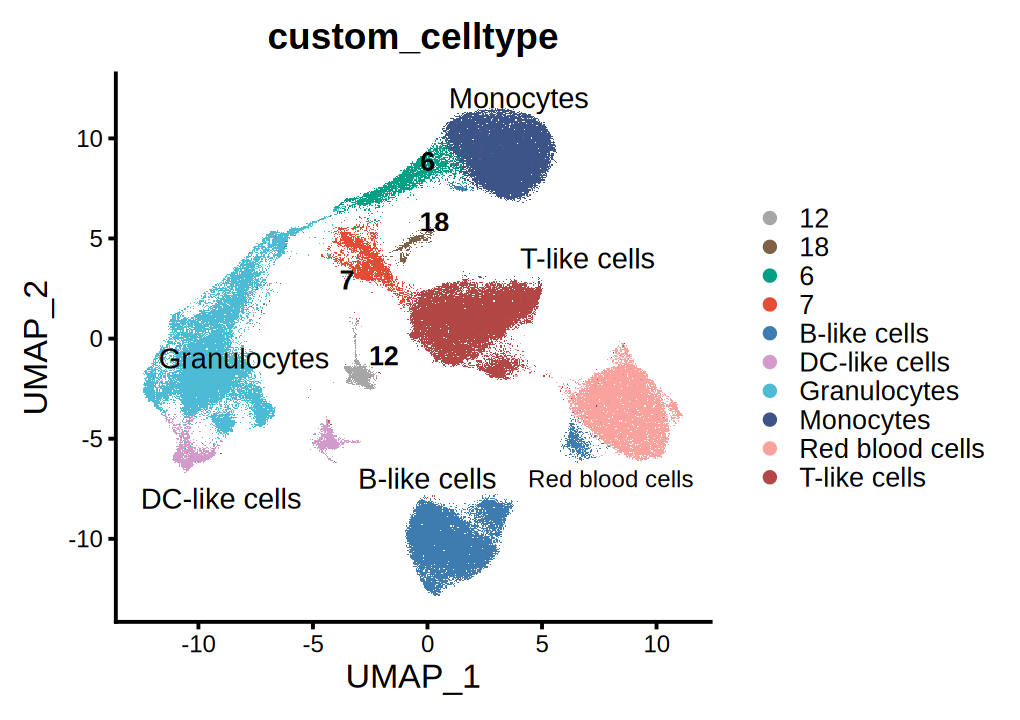

In [21]:
library(Seurat)
library(ggplot2)
library(dplyr)
library(ggrepel)

options(repr.plot.width = 8.5, repr.plot.height = 6)

# UMAP coordinates + metadata
umap_df <- Embeddings(blood_sc, reduction = "umap") %>%
  as.data.frame() %>%
  tibble::rownames_to_column("cell")

meta_df <- blood_sc@meta.data %>%
  as.data.frame() %>%
  tibble::rownames_to_column("cell")

plot_df <- left_join(umap_df, meta_df, by = "cell")

# Only keep the numeric clusters you want to label
num_clusters <- c("7", "6", "12", "18")

# Compute cluster label positions (median is usually more stable than mean)
num_label_df <- plot_df %>%
  filter(custom_celltype %in% num_clusters) %>%
  group_by(custom_celltype) %>%
  summarise(
    UMAP_1 = median(UMAP_1),
    UMAP_2 = median(UMAP_2),
    .groups = "drop"
  )

p <- DimPlot(
  blood_sc,
  reduction = "umap",
  group.by = "custom_celltype",
  cols = blood_colors,
  label = FALSE,
  pt.size = 1
) +
  theme_classic(base_size = 18) +
  theme(
    plot.title = element_text(size = 22, face = "bold", hjust = 0.5),
    axis.title = element_text(size = 20),
    axis.text = element_text(size = 14),
    legend.title = element_blank(),
    legend.text = element_text(size = 16)
  ) +
  annotate("text", x = 7, y = 4, label = "T-like cells", size = 6) +
  annotate("text", x = 8, y = -7, label = "Red blood cells", size = 5) +
  annotate("text", x = 0, y = -7, label = "B-like cells", size = 6) +
  annotate("text", x = 4, y = 12.0, label = "Monocytes", size = 6) +
  annotate("text", x = -8, y = -1.0, label = "Granulocytes", size = 6) +
  annotate("text", x = -9.0, y = -8, label = "DC-like cells", size = 6) +
  geom_text_repel(
    data = num_label_df,
    aes(x = UMAP_1, y = UMAP_2, label = custom_celltype),
    inherit.aes = FALSE,
    size = 5.5,
    fontface = "bold",
    color = "black",
    box.padding = 0.4,
    point.padding = 0.3,
    segment.color = NA
  )

p

Gill

In [5]:
gill_sc@meta.data$newcell <- as.character(gill_sc@meta.data$newcell)
gill_sc@meta.data$newcell[gill_sc@meta.data$newcell == "VLRC cell"] <- "T-like cells"
gill_sc@meta.data$newcell[gill_sc@meta.data$newcell == "VLRB cell"] <- "B-like cells"
gill_sc@meta.data$newcell[gill_sc@meta.data$newcell == "Endothelial cell"] <- "Epithelial cell"

In [6]:
# First check the current cluster column
head(gill_sc@meta.data$RNA_snn_res.0.5)
table(gill_sc@meta.data$RNA_snn_res.0.5)

# Create a new column by copying the original cluster IDs
gill_sc$custom_celltype <- as.character(gill_sc$RNA_snn_res.0.5)

# Replace only selected clusters with custom labels
gill_sc$custom_celltype[gill_sc$custom_celltype == "0"] <- "Red blood cells"
gill_sc$custom_celltype[gill_sc$custom_celltype == "9"] <- "Red blood cells"
gill_sc$custom_celltype[gill_sc$custom_celltype == "2"] <- "T-like cells"
gill_sc$custom_celltype[gill_sc$custom_celltype == "10"] <- "B-like cells"
gill_sc$custom_celltype[gill_sc$custom_celltype == "1"] <- "Epithelial cells"
gill_sc$custom_celltype[gill_sc$custom_celltype == "1"] <- "Epithelial cells"
gill_sc$custom_celltype[gill_sc$custom_celltype == "3"] <- "Epithelial cells"
gill_sc$custom_celltype[gill_sc$custom_celltype == "5"] <- "Epithelial cells"
gill_sc$custom_celltype[gill_sc$custom_celltype == "7"] <- "Epithelial cells"
gill_sc$custom_celltype[gill_sc$custom_celltype == "11"] <- "Epithelial cells"
gill_sc$custom_celltype[gill_sc$custom_celltype == "12"] <- "Epithelial cells"
gill_sc$custom_celltype[gill_sc$custom_celltype == "13"] <- "DC-like cells"
gill_sc$custom_celltype[gill_sc$custom_celltype == "8"] <- "Granulocytes"
# Check result
table(gill_sc$custom_celltype)
head(gill_sc@meta.data)

[1] 4  0  13 0  0  0 
Levels: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17


   0    1    2    3    4    5    6    7    8    9   10   11   12   13   14   15 
4234 2707 2630 1353  657  637  628  583  560  437  396  313  301  276  269  191 
  16   17 
 152  123 


              14               15               16               17 
             269              191              152              123 
               4                6     B-like cells    DC-like cells 
             657              628              396              276 
Epithelial cells     Granulocytes  Red blood cells     T-like cells 
            5894              560             4671             2630 

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,celltype,subtype,tissue,batch,RNA_snn_res.0.5,newcell,custom_celltype
,<chr>,<dbl>,<int>,<dbl>,<fct>,<fct>,<chr>,<chr>,<fct>,<chr>,<chr>
CELL2_N1_1,Gill-1,3560,431,0,Ionocyte,Ionocyte-4,gill,Gill-1,4,Ionocyte,4
CELL3_N1_1,Gill-1,1396,239,0,Erythroblasts,Erythroblasts-0,gill,Gill-1,0,Red blood cells,Red blood cells
CELL4_N1_1,Gill-1,1273,575,0,Langerhans Cells,Langerhans Cells-13,gill,Gill-1,13,dendritic cell,DC-like cells
CELL7_N1_1,Gill-1,2304,281,0,Erythroblasts,Erythroblasts-0,gill,Gill-1,0,Red blood cells,Red blood cells
CELL8_N1_1,Gill-1,1969,261,0,Erythroblasts,Erythroblasts-0,gill,Gill-1,0,Red blood cells,Red blood cells
CELL10_N1_1,Gill-1,1860,205,0,Erythroblasts,Erythroblasts-0,gill,Gill-1,0,Red blood cells,Red blood cells


In [7]:
Assays(gill_sc)
DefaultAssay(gill_sc) <- "RNA"

# Seurat v4
dim(GetAssayData(gill_sc, assay = "RNA", slot = "counts"))

[1] "RNA" "SCT"

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.”


[1] 19334 16447

In [8]:
gill_colors <- c(
  "14" = "#7DA6D9",
  "15" = "#00A087",
  "16" = "#E64B35",
  "17" = "#7E6143",
 "4" = "#B08B6B",
  "6"  = "#A6A6A6",
  "B-like cells" = "#3E7CB1",
  "DC-like cells" = "#D39BCB",
  "Epithelial cells" = "#F38160",
  "Granulocytes" = "#4DBBD5",
  "Red blood cells" = "#FAA39E",
  "T-like cells" = "#B24745"
)

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


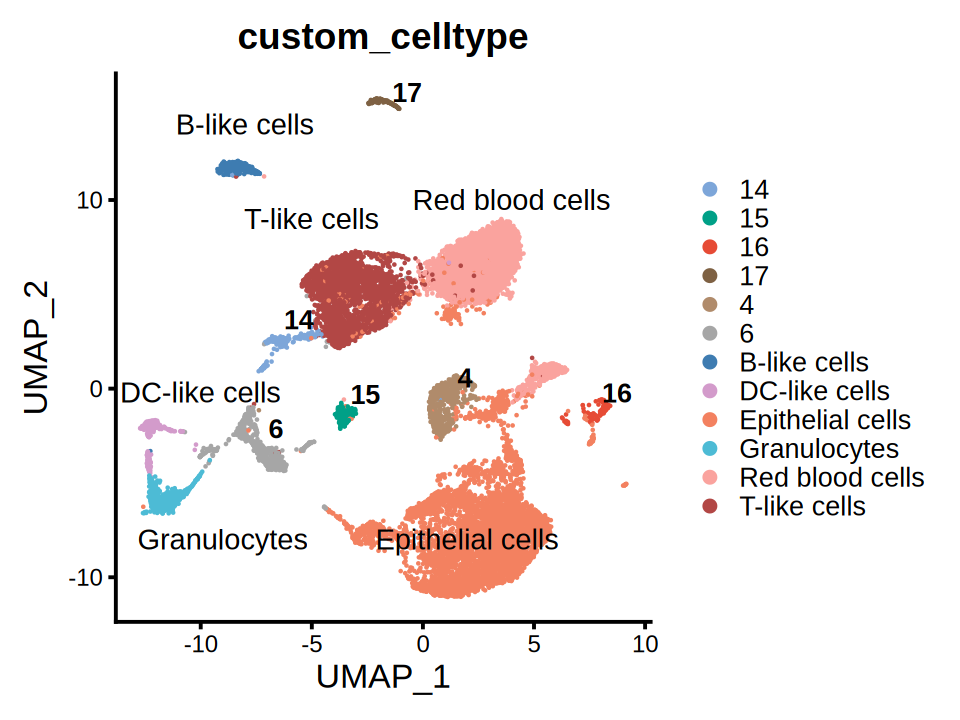

In [9]:
library(Seurat)
library(ggplot2)
library(dplyr)
library(ggrepel)

options(repr.plot.width = 8, repr.plot.height = 6)

# UMAP coordinates + metadata
umap_df <- Embeddings(gill_sc, reduction = "umap") %>%
  as.data.frame() %>%
  tibble::rownames_to_column("cell")

meta_df <- gill_sc@meta.data %>%
  as.data.frame() %>%
  tibble::rownames_to_column("cell")

plot_df <- left_join(umap_df, meta_df, by = "cell")

# Only keep the numeric clusters you want to label
num_clusters <- c("4", "6", "14", "15", "16", "17")

# Compute cluster label positions (median is usually more stable than mean)
num_label_df <- plot_df %>%
  filter(custom_celltype %in% num_clusters) %>%
  group_by(custom_celltype) %>%
  summarise(
    UMAP_1 = median(UMAP_1),
    UMAP_2 = median(UMAP_2),
    .groups = "drop"
  )

p <- DimPlot(
  gill_sc,
  reduction = "umap",
  group.by = "custom_celltype",
  cols = gill_colors,
  label = FALSE,
  pt.size = 0.1
) +
  theme_classic(base_size = 18) +
  theme(
    plot.title = element_text(size = 22, face = "bold", hjust = 0.5),
    axis.title = element_text(size = 20),
    axis.text = element_text(size = 14),
    legend.title = element_blank(),
    legend.text = element_text(size = 16)
  ) +
  annotate("text", x = -5, y = 9, label = "T-like cells", size = 6) +
  annotate("text", x = 4, y = 10, label = "Red blood cells", size = 6) +
  annotate("text", x = -8.0, y = 14.0, label = "B-like cells", size = 6) +
  annotate("text", x = 2, y = -8.0, label = "Epithelial cells", size = 6) +
  annotate("text", x = -9.0, y = -8.0, label = "Granulocytes", size = 6) +
  annotate("text", x = -10.0, y = -0.2, label = "DC-like cells", size = 6) +
  geom_text_repel(
    data = num_label_df,
    aes(x = UMAP_1, y = UMAP_2, label = custom_celltype),
    inherit.aes = FALSE,
    size = 5.5,
    fontface = "bold",
    color = "black",
    box.padding = 0.4,
    point.padding = 0.3,
    segment.color = NA
  )

p

Intestine

In [22]:
intestine_sc@meta.data$newcell <- as.character(intestine_sc@meta.data$newcell)
intestine_sc@meta.data$newcell[intestine_sc@meta.data$newcell == "VLRC cell"] <- "T-like cells"
intestine_sc@meta.data$newcell[intestine_sc@meta.data$newcell == "VLRB cell"] <- "B-like cells"

In [23]:
# First check the current cluster column
head(intestine_sc@meta.data$RNA_snn_res.0.5)
table(intestine_sc@meta.data$RNA_snn_res.0.5)

# Create a new column by copying the original cluster IDs
intestine_sc$custom_celltype <- as.character(intestine_sc$RNA_snn_res.0.5)

# Replace only selected clusters with custom labels
intestine_sc$custom_celltype[intestine_sc$custom_celltype == "0"] <- "T-like cells"
intestine_sc$custom_celltype[intestine_sc$custom_celltype == "1"] <- "Granulocytes"
intestine_sc$custom_celltype[intestine_sc$custom_celltype == "2"] <- "T-like cells"
intestine_sc$custom_celltype[intestine_sc$custom_celltype == "3"] <- "Red blood cells"
intestine_sc$custom_celltype[intestine_sc$custom_celltype == "4"] <- "Granulocytes"
intestine_sc$custom_celltype[intestine_sc$custom_celltype == "5"] <- "B-like cells"
intestine_sc$custom_celltype[intestine_sc$custom_celltype == "8"] <- "Epithelial cells"
intestine_sc$custom_celltype[intestine_sc$custom_celltype == "10"] <- "T-like cells"
intestine_sc$custom_celltype[intestine_sc$custom_celltype == "11"] <- "DC-like cells"
intestine_sc$custom_celltype[intestine_sc$custom_celltype == "13"] <- "Epithelial cells"
intestine_sc$custom_celltype[intestine_sc$custom_celltype == "15"] <- "Red blood cells"
intestine_sc$custom_celltype[intestine_sc$custom_celltype == "16"] <- "Granulocytes"
intestine_sc$custom_celltype[intestine_sc$custom_celltype == "20"] <- "Epithelial cells"
intestine_sc$custom_celltype[intestine_sc$custom_celltype == "21"] <- "Epithelial cells"
intestine_sc$custom_celltype[intestine_sc$custom_celltype == "25"] <- "Granulocytes"
# Check result
table(intestine_sc$custom_celltype)
head(intestine_sc@meta.data)

[1] 4 1 3 1 1 5
26 Levels: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 ... 25


    0     1     2     3     4     5     6     7     8     9    10    11    12 
11054  7433  5310  5298  3115  2979  2507  2304  1923  1550  1237   909   778 
   13    14    15    16    17    18    19    20    21    22    23    24    25 
  756   689   428   368   305   240   236   227   153   135    92    75    34 


              12               14               17               18 
             778              689              305              240 
              19               22               23               24 
             236              135               92               75 
               6                7                9     B-like cells 
            2507             2304             1550             2979 
   DC-like cells Epithelial cells     Granulocytes  Red blood cells 
             909             3059            10950             5726 
    T-like cells 
           17601 

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,celltype,subtype,tissue,batch,RNA_snn_res.0.5,newcell,custom_celltype
,<chr>,<dbl>,<int>,<dbl>,<fct>,<fct>,<chr>,<chr>,<fct>,<chr>,<chr>
CELL1_N1_1,intestine-1,1759,629,0,neutrophil,neutrophil_4,intestine,intestine-1,4,Granulocyte,Granulocytes
CELL2_N1_1,intestine-1,1441,606,0,neutrophil,neutrophil_1,intestine,intestine-1,1,Granulocyte,Granulocytes
CELL3_N1_1,intestine-1,2922,610,0,Erythroblasts,Erythroblasts_3,intestine,intestine-1,3,Red blood cells,Red blood cells
CELL5_N1_1,intestine-1,1511,607,0,neutrophil,neutrophil_1,intestine,intestine-1,1,Granulocyte,Granulocytes
CELL6_N1_1,intestine-1,1055,477,0,neutrophil,neutrophil_1,intestine,intestine-1,1,Granulocyte,Granulocytes
CELL7_N1_1,intestine-1,1389,484,0,macrophage,macrophage_5,intestine,intestine-1,5,B-like cells,B-like cells


In [24]:
intestine_colors <- c(
  "Granulocytes"                       = "#4DBBD5",   # 浅蓝青（保留）
  "Red blood cells"                   = "#FAA39E",   # 鲜红（保留）
  "B-like cells"                         = "#3E7CB1",   # 深蓝紫（保留）
  "17"                          = "#BC80BD",   # 淡紫丁香
  "Epithelial cells"                  = "#FDB462",   # 橙黄色
  "T-like cells"                = "#B24745",   # 深砖红（保留）、
  "6"                          = "#8DD3C7",   # 浅青绿
  "7"                        = "#B3DE69",   # 青绿色偏黄
  "18"                       = "#FFED6F",   # 柠檬黄
  "19"                 = "#FB8072",   # 西瓜红
  "DC-like cells" = "#A6CEE3",   # 浅蓝
  "12"                         = "#FDBF6F",   # 橘黄
  "9"                       = "#00A087",   # 青绿色（保留）
  "23"                        = "#CAB2D6",   # 淡紫灰
  #"Monocyte"                          = "#3C5488",   # 深蓝灰（保留）
  "24"                       = "#999999",   # 中性灰
  "14"                       = "#FF7F00",   # 橙色
  "22"             = "#6A3D9A"    # 深紫
)

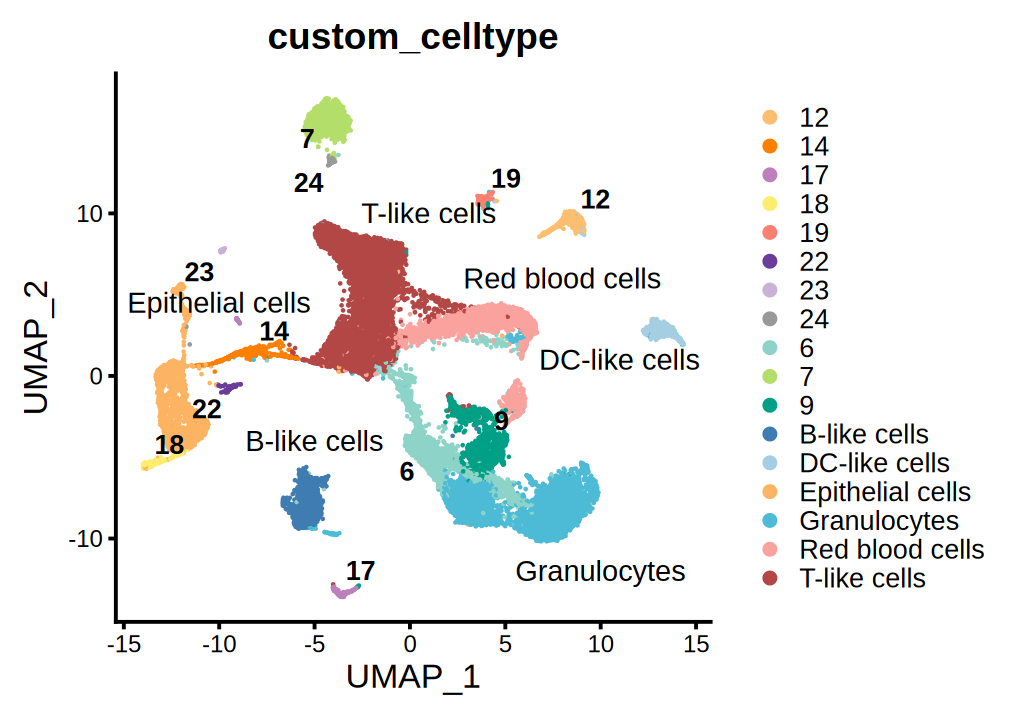

In [25]:
library(Seurat)
library(ggplot2)
library(dplyr)
library(ggrepel)

options(repr.plot.width = 8.5, repr.plot.height = 6)

# UMAP coordinates + metadata
umap_df <- Embeddings(intestine_sc, reduction = "umap") %>%
  as.data.frame() %>%
  tibble::rownames_to_column("cell")

meta_df <- intestine_sc@meta.data %>%
  as.data.frame() %>%
  tibble::rownames_to_column("cell")

plot_df <- left_join(umap_df, meta_df, by = "cell")

# Only keep the numeric clusters you want to label
num_clusters <- c("6", "7", "9", "12","14", "17", "18", "19","22", "23", "24")

# Compute cluster label positions (median is usually more stable than mean)
num_label_df <- plot_df %>%
  filter(custom_celltype %in% num_clusters) %>%
  group_by(custom_celltype) %>%
  summarise(
    UMAP_1 = median(UMAP_1),
    UMAP_2 = median(UMAP_2),
    .groups = "drop"
  )

p <- DimPlot(
  intestine_sc,
  reduction = "umap",
  group.by = "custom_celltype",
  cols = intestine_colors,
  label = FALSE,
  pt.size = 0.1
) +
  theme_classic(base_size = 18) +
  theme(
    plot.title = element_text(size = 22, face = "bold", hjust = 0.5),
    axis.title = element_text(size = 20),
    axis.text = element_text(size = 14),
    legend.title = element_blank(),
    legend.text = element_text(size = 16)
  ) +
  annotate("text", x = 1, y = 10, label = "T-like cells", size = 6) +
  annotate("text", x = 8, y = 6, label = "Red blood cells", size = 6) +
  annotate("text", x = -5, y = -4, label = "B-like cells", size = 6) +
  #annotate("text", x = -7, y = 10.5, label = "Monocyte", size = 6) +
  annotate("text", x = 10, y = -12, label = "Granulocytes", size = 6) +
  annotate("text", x = 11, y = 1, label = "DC-like cells", size = 6) +
  annotate("text", x = -10.0, y = 4.5, label = "Epithelial cells", size = 6) +
  geom_text_repel(
    data = num_label_df,
    aes(x = UMAP_1, y = UMAP_2, label = custom_celltype),
    inherit.aes = FALSE,
    size = 5.5,
    fontface = "bold",
    color = "black",
    box.padding = 0.4,
    point.padding = 0.3,
    segment.color = NA
  )

p

# Merge

In [27]:
library(harmony)

Loading required package: Rcpp



In [28]:
gill_sc$batch <- "gill"
blood_sc$batch <- "blood"
intestine_sc$batch <- "intestine"

In [31]:
objs <- list(gill_sc, blood_sc, intestine_sc)

objs <- lapply(objs, function(x) {
  DefaultAssay(x) <- "RNA"
  if ("SCT" %in% Assays(x)) {
    x[["SCT"]] <- NULL
  }
  x
})

merge_sc <- merge(
  x = objs[[1]],
  y = objs[2:3],
  add.cell.ids = c("gill", "blood", "intestine"),
  merge.data = FALSE
)

merge_sc <- SCTransform(merge_sc, verbose = FALSE)

Warning message:
“The `slot` argument of `SetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


In [32]:
merge_sc$batch <- dplyr::case_when(
  grepl("^Gill", merge_sc$orig.ident, ignore.case = TRUE) ~ "gill",
  grepl("^blood", merge_sc$orig.ident, ignore.case = TRUE) ~ "blood",
  grepl("^intestine", merge_sc$orig.ident, ignore.case = TRUE) ~ "intestine",
  TRUE ~ NA_character_
)

In [35]:
DefaultAssay(merge_sc) <- "RNA"

In [36]:
merge_sc[["RNA"]] <- split(merge_sc[["RNA"]], f = merge_sc$batch)

Warning message:
“Input is a v3 assay and `split()` only works for v5 assays; converting
• to a v5 assay”
Warning message:
“Assay RNA changing from Assay to Assay5”


In [37]:
merge_sc <- merge_sc %>% NormalizeData(verbose = F) %>% 
    FindVariableFeatures(verbose = F) %>% 
    ScaleData(verbose = F) %>% 
    RunPCA(npcs = 30, verbose = FALSE)

In [38]:
merge_sc.harmony <- IntegrateLayers(object = merge_sc, method = HarmonyIntegration,
                         orig.reduction = "pca", new.reduction = "harmony",
                         normalization.method = "RNA", verbose = FALSE) %>% 
    RunUMAP(reduction = "harmony", dims = 1:30,seed.use = 42,
            verbose = FALSE,reduction.name = "umap.harmony") %>% 
    RunTSNE(reduction = "harmony", dims = 1:30, verbose = FALSE,seed.use = 42) 

The `features` argument is ignored by `HarmonyIntegration`.
This message is displayed once per session.
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 9861800)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 9861800)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 9861800)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 9861800)”
Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


In [40]:
merge_sc_harmony <- readRDS("/home/yating/VLR/merge_sc.harmony_beforecluster.rds")

# FigureS1a-b

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



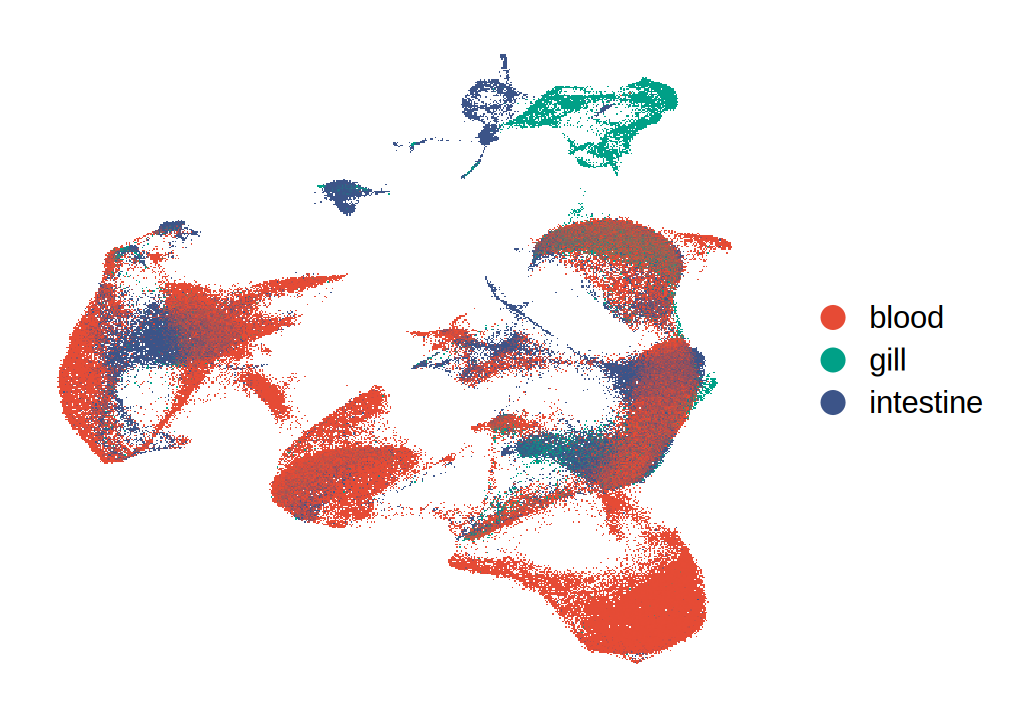

In [41]:
library(grid)
library(ggplot2)
library(Seurat)

p_batch <- DimPlot(
  merge_sc_harmony,
  reduction = "umap.harmony",
  group.by = "batch",
  pt.size = 1
) +
  scale_color_manual(values = c(
    "blood"     = "#E64B35",
    "gill"      = "#00A087",
    "intestine" = "#3C5488"
  )) +
  guides(
    color = guide_legend(
      override.aes = list(size = 6)   # 图例圆点更大
    )
  ) +
  theme_classic(base_size = 18) +
  theme(
    axis.title = element_blank(),
    axis.text = element_blank(),
    axis.ticks = element_blank(),
    axis.line = element_blank(),
    legend.position = "right",
    legend.title = element_blank(),
    plot.title = element_blank(),

    # 图例字体和间距
    legend.text = element_text(size = 18, face = "plain", colour = "black"),
    legend.key.height = unit(0.9, "cm"),
    legend.key.width  = unit(0.9, "cm")
  )

p_batch

In [42]:
merge_sc_harmony <- merge_sc_harmony %>% FindNeighbors(dims = 1:30, reduction = "harmony",verbose = F) %>% 
    FindClusters(resolution = c(0.1,0.2,0.4,0.6),verbose = F)

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



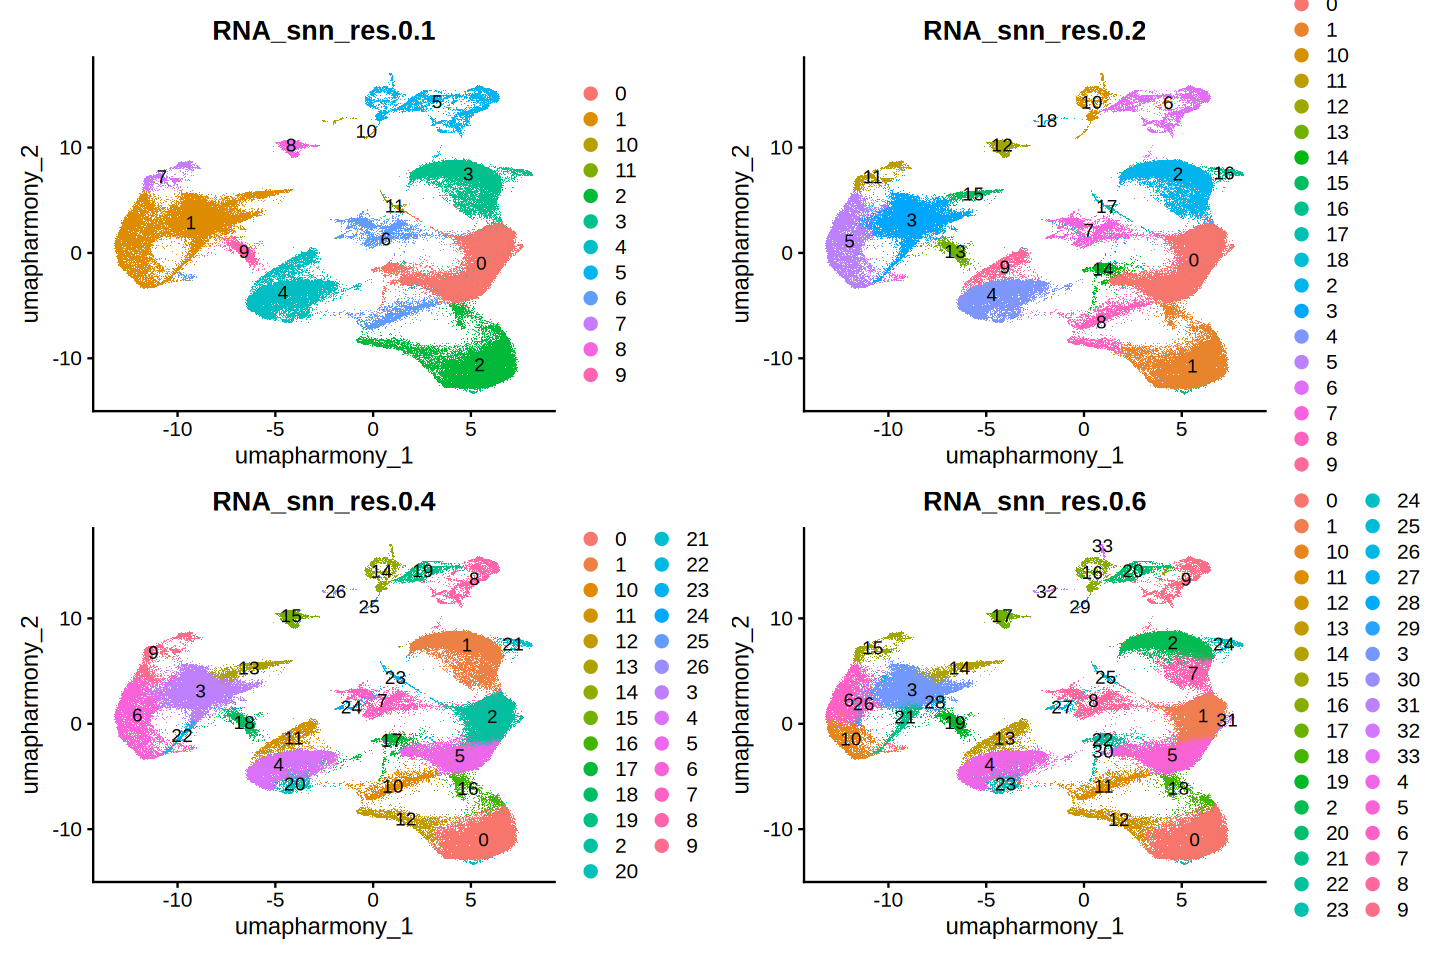

In [43]:
options(repr.plot.width = 12,repr.plot.height = 8)
DimPlot(merge_sc_harmony,reduction = "umap.harmony",
        group.by = c("RNA_snn_res.0.1","RNA_snn_res.0.2","RNA_snn_res.0.4","RNA_snn_res.0.6"),label = T)

In [44]:
merge_sc_harmony[['RNA']] <- JoinLayers(merge_sc_harmony[["RNA"]])

In [45]:
DefaultAssay(merge_sc_harmony) <- "RNA"
Idents(merge_sc_harmony) <- "RNA_snn_res.0.2"

In [47]:
new.cluster.ids <- c(
  "0" = "T-like cells",
  "1" = "Monocytes",
  "2" = "Red blood cells",
  "3" = "Granulocytes",
  "4" = "B-like cells",
  "5" = "Granulocytes",
  "6" = "Epithelial cells",
  "7" = "7",
  "8" = "8",
  "9" = "B-like cells",
  "10" = "T-like cells",
  "11" = "DC-like cells",
  "12" = "12",
  "13" = "B-like cells",
  "14" = "T-like cells",
  "15" = "Red blood cells",
  "16" = "Red blood cells",
  "17" = "17",
  "18" = "18"
)

merge_sc_harmony <- RenameIdents(merge_sc_harmony, new.cluster.ids)

merge_sc_harmony[["celltype_harmony"]] <- Idents(merge_sc_harmony)

In [48]:
harmony_colors <- c(
  "Granulocytes"                       = "#4DBBD5",   # 浅蓝青（保留）
  "Red blood cells"                   = "#FAA39E",   # 鲜红（保留）
  "B-like cells"                         = "#3E7CB1",   # 深蓝紫（保留）
  "Epithelial cells"                  = "#F38160",   # 橙黄色
  "T-like cells"                = "#B24745",   # 深砖红（保留）
  "7"                          = "#8DD3C7",   # 浅青绿
  "12"                  = "#B3DE69",   # 青绿色偏黄
  "DC-like cells"                               = "#A6CEE3",   # 浅蓝
  "Monocytes"                          = "#3C5488",   # 深蓝灰（保留）
  "17"                       = "#FF7F00",   # 橙色
  "18"             = "#6A3D9A",    # 深紫
  "8"               = "#A6A6A6"
)

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



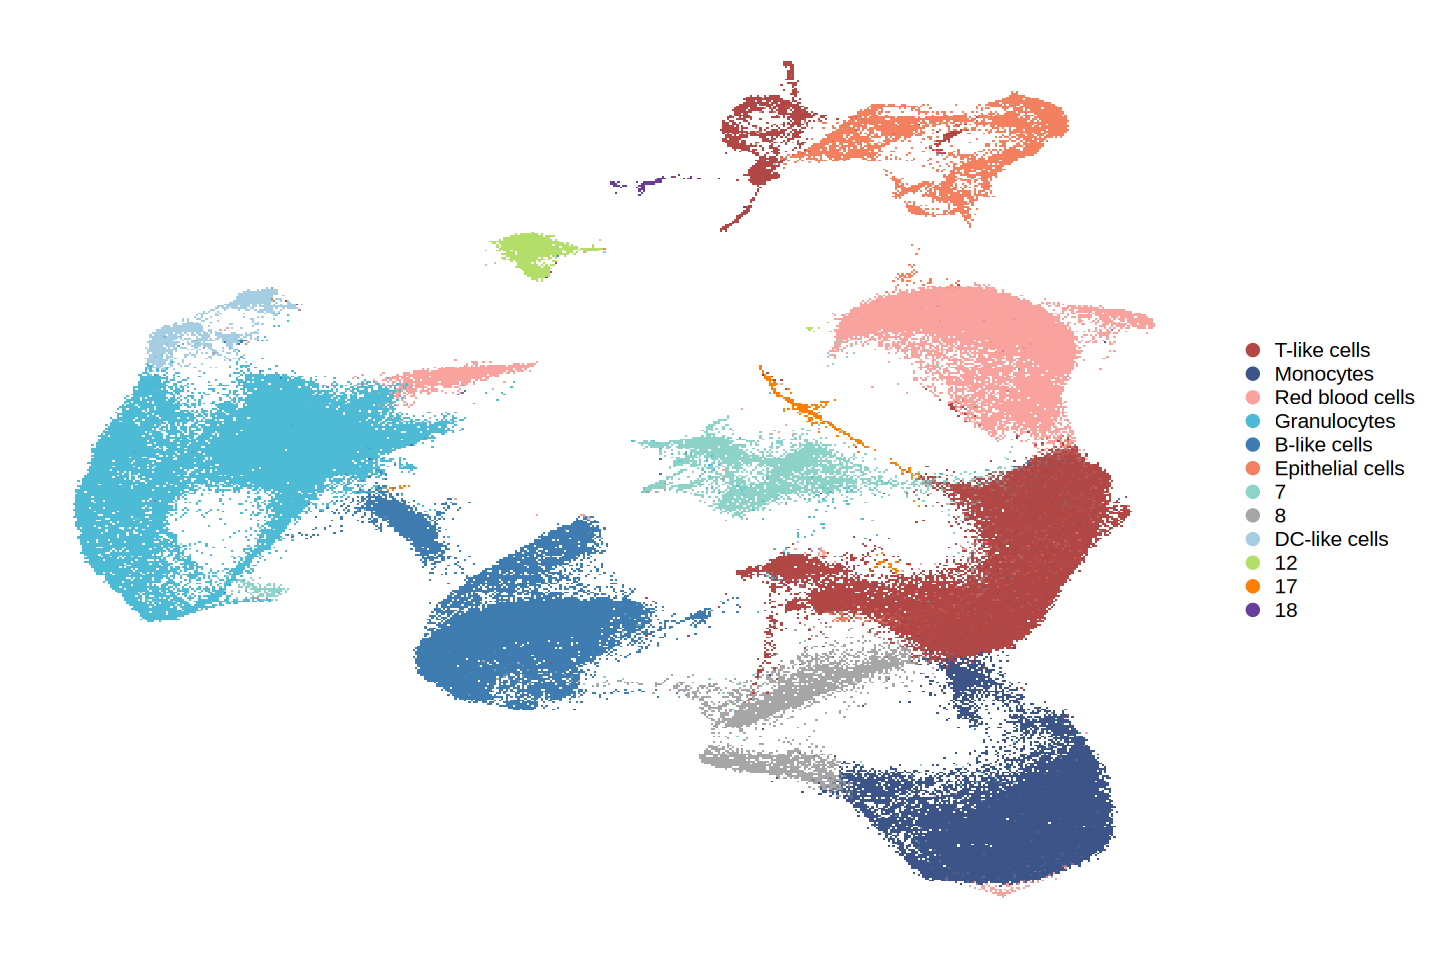

In [49]:
library(grid)

DimPlot(merge_sc_harmony, group.by = "celltype_harmony") +
  scale_color_manual(values = harmony_colors) +
  guides(
    color = guide_legend(
      override.aes = list(size = 3)
    )
  ) +
  theme_minimal(base_size = 12) +
  theme(
    panel.grid = element_blank(),
    axis.title.x = element_blank(),
    axis.title.y = element_blank(),
    axis.text = element_blank(),
    axis.ticks = element_blank(),
    legend.position = "right",
    legend.title = element_blank(),
    plot.title = element_blank(),

    # 调大字体和间距
    legend.text = element_text(size = 12, face = "plain", colour = "black"),
    legend.key.size = unit(0.5, "cm"),
    legend.spacing.y = unit(0.18, "cm")
  )

options(repr.plot.width = 6, repr.plot.height = 4)

# Figure1b

In [50]:
library(ComplexHeatmap)
library(RColorBrewer)
library(circlize)
library(viridis)

ComplexHeatmap version 2.18.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))
! pheatmap() has been masked by ComplexHeatmap::pheatmap(). Most of the arguments
   in the original pheatmap() are identically supported in the new function. You 
   can still use the original function by explicitly calling pheatmap::pheatmap().



Attaching package: ‘ComplexHeatmap’


The following ob

In [51]:
merge_sc.harmony1 <- merge_sc_harmony

In [52]:
sub_merge_sc.harmony <- subset(merge_sc.harmony1, 
                  subset = celltype_harmony %in% c("T-like cells", "B-like cells"))

In [53]:
VLR_TB_markers <- FindMarkers(
  sub_merge_sc.harmony,
  ident.1 = "T-like cells",
  ident.2 = "B-like cells",
  group.by = "celltype_harmony",
  min.pct = 0.25,
  logfc.threshold = 0.25
)

Warning message:
“`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


In [55]:
# VLRB cell marker genes
vlrb_markers <- c(
  "MSTRG.4638","MSTRG.6505", "MSTRG.4356", "MSTRG.8810", "nbisL1-mrna-17203"
)

# VLRC cell marker genes
vlrc_markers <- c(
  "nbisL1-mrna-4804", "nbisL1-mrna-8677", "nbisL1-mrna-15664", 
  "MSTRG.4829", "MSTRG.31304", "MSTRG.31308", "nbisL1-mrna-15650")

# 合并为统一 marker gene 列表（用于热图）
marker_genes <- c(vlrb_markers, vlrc_markers)

In [56]:
deg_T <- VLR_TB_markers %>%
  filter(avg_log2FC > 0.5, p_val_adj < 0.05) %>%
  filter(!rownames(.) %in% marker_genes) %>%
  arrange(desc(avg_log2FC)) %>%
  head(15) %>%
  rownames()

deg_B <- VLR_TB_markers %>%
  filter(avg_log2FC < -0.5, p_val_adj < 0.05) %>%
  filter(!rownames(.) %in% marker_genes) %>%
  arrange(avg_log2FC) %>%
  head(15) %>%
  rownames()

all_genes <- c(vlrb_markers, vlrc_markers, deg_B, deg_T)

In [57]:
remove_genes <- c(
  "MSTRG.4209", "MSTRG.23556", "MSTRG.23758", 
  "MSTRG.7322", "MSTRG.7320", "MSTRG.2966", "MSTRG.14367","nbisL1-mrna-8869","nbisL1-mrna-13623","MSTRG.18764","MSTRG.1417","MSTRG.28039",
    "MSTRG.17016","nbisL1-mrna-14418"
)

all_genes_filtered <- setdiff(all_genes, remove_genes)

In [58]:
#all_genes <- c(marker_genes, top_deg_genes_filtered)
expr_mat <- GetAssayData(sub_merge_sc.harmony, assay = "RNA", slot = "data")
expr_mat_use <- expr_mat[all_genes_filtered, ]
expr_mat_use <- expr_mat_use[, colSums(expr_mat_use) != 0]
expr_scaled <- t(scale(t(expr_mat_use), center = TRUE, scale = TRUE))
expr_scaled[is.na(expr_scaled)] <- 0

In [59]:
rownames(expr_scaled) <- all_genes_filtered  # 明确设定行名

In [60]:
# Clip extreme expression
expr_scaled[expr_scaled > 6] <- 6
expr_scaled[expr_scaled < -2] <- -2

In [63]:
annotation_col <- data.frame(
  Tissue = sub_merge_sc.harmony$tissue,
  CellType = sub_merge_sc.harmony$celltype_harmony
)
rownames(annotation_col) <- colnames(sub_merge_sc.harmony)
# 先只保留 expr_scaled 中存在的细胞
annotation_col <- annotation_col[colnames(expr_scaled), , drop = FALSE]

# 再排序：先 CellType，再 Region
ordered_cells <- rownames(annotation_col)[order(annotation_col$CellType, annotation_col$Tissue)]

# 排序表达矩阵和注释
expr_scaled_ordered <- expr_scaled[, ordered_cells]
annotation_col_ordered <- annotation_col[ordered_cells, , drop = FALSE]

In [64]:
#all_genes <- unique(c(marker_genes, top_deg_genes))
gene_group <- ifelse(all_genes_filtered %in% marker_genes, "Marker", "DEG")
annotation_row <- data.frame(Group = gene_group)
rownames(annotation_row) <- all_genes_filtered

ann_colors <- list(
  CellType = c("T-like cells" = "#D73027", "B-like cells" = "#4575B4"),
  Tissue = c("gill" = "#66C2A5", "blood" = "#8DA0CB", "intestine" = "#FC8D62"),
  Group = c("Marker" = "#E41A1C", "DEG" = "#377EB8")
)

In [65]:
# 强制指定分组顺序：Marker 在上
annotation_row$Group <- factor(annotation_row$Group, levels = c("Marker", "DEG"))

In [66]:
library(ComplexHeatmap)
library(grid)
library(viridis)

# -------- 数据范围和分组 --------
mat_plot <- expr_scaled_ordered
mat_plot[mat_plot > 6] <- 6
mat_plot[mat_plot < -2] <- -2

row_split_vec <- droplevels(annotation_row[rownames(mat_plot), "Group"])
annotation_col_ordered <- annotation_col[colnames(mat_plot), , drop = FALSE]

# -------- 统一生成 Heatmap 的函数 --------
make_ht <- function(use_raster_setting = FALSE) {
  Heatmap(
    mat_plot,
    name = "Z-score",
    show_column_names = FALSE,
    show_row_names = TRUE,
    row_names_gp = gpar(fontsize = 10),
    row_names_max_width = max_text_width(rownames(mat_plot), gp = gpar(fontsize = 10)) + unit(2, "mm"),
    cluster_rows = FALSE,
    cluster_columns = FALSE,
    top_annotation = HeatmapAnnotation(
      CellType = annotation_col_ordered$CellType,
      Tissue   = annotation_col_ordered$Tissue,
      col = ann_colors
    ),
    row_split = row_split_vec,
    col = viridis::viridis(100, option = "D"),
    heatmap_legend_param = list(
      at = c(-2, 0, 2, 4, 6)
    ),
    width = unit(24, "cm"),   # 热图主体宽度，关键
    height = unit(26, "cm"),  # 热图主体高度
    use_raster = use_raster_setting,
    raster_quality = 5
  )
}

outdir <- "/home/yating/VLR"
dir.create(outdir, recursive = TRUE, showWarnings = FALSE)

# -------- 1) 矢量 PDF：最适合放大检查 --------
ht_pdf <- make_ht(use_raster_setting = FALSE)

cairo_pdf(
  file.path(outdir, "Fig1b_heatmap_vector.pdf"),
  width = 16, height = 12
)
draw(
  ht_pdf,
  merge_legend = TRUE,
  heatmap_legend_side = "right",
  annotation_legend_side = "right"
)
dev.off()

# -------- 2) 高清 PNG-------
ht_png <- make_ht(use_raster_setting = TRUE)

png(
  file.path(outdir, "Fig1b_heatmap_highres.png"),
  width = 8000, height = 6000, res = 600,
  type = "cairo", antialias = "subpixel"
)
draw(
  ht_png,
  merge_legend = TRUE,
  heatmap_legend_side = "right",
  annotation_legend_side = "right"
)
dev.off()

pdf 
  2

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



pdf 
  2

# Figure1c

In [67]:
Idents(merge_sc_harmony) <- "celltype_harmony"

In [68]:
merge_sc_harmony@meta.data

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,celltype,subtype,tissue,batch,RNA_snn_res.0.5,newcell,RNA_snn_res.1,seurat_clusters,subname,RNA_snn_res.0.1,RNA_snn_res.0.2,RNA_snn_res.0.4,RNA_snn_res.0.6,celltype_harmony
,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<chr>,<fct>,<fct>,<fct>,<fct>,<fct>
gill_CELL2_N1_1,Gill-1,3560,431,0,Ionocyte,Ionocyte-4,gill,gill,4,Ionocyte,NA,9,NA,5,6,8,9,Epithelial cells
gill_CELL3_N1_1,Gill-1,1396,239,0,Erythroblasts,Erythroblasts-0,gill,gill,0,Red blood cells,NA,2,NA,3,2,1,2,Red blood cells
gill_CELL4_N1_1,Gill-1,1273,575,0,Langerhans Cells,Langerhans Cells-13,gill,gill,13,dendritic cell,NA,15,NA,7,11,9,15,DC-like cells
gill_CELL7_N1_1,Gill-1,2304,281,0,Erythroblasts,Erythroblasts-0,gill,gill,0,Red blood cells,NA,2,NA,3,2,1,2,Red blood cells
gill_CELL8_N1_1,Gill-1,1969,261,0,Erythroblasts,Erythroblasts-0,gill,gill,0,Red blood cells,NA,2,NA,3,2,1,2,Red blood cells
gill_CELL10_N1_1,Gill-1,1860,205,0,Erythroblasts,Erythroblasts-0,gill,gill,0,Red blood cells,NA,2,NA,3,2,1,2,Red blood cells
gill_CELL12_N1_1,Gill-1,2741,382,0,Erythroblasts,Erythroblasts-0,gill,gill,0,Red blood cells,NA,2,NA,3,2,1,2,Red blood cells
gill_CELL13_N1_1,Gill-1,1786,837,0,Epithelial Cells,Epithelial Cells-1,gill,gill,1,Epithelial cell,NA,9,NA,5,6,8,9,Epithelial cells
gill_CELL14_N1_1,Gill-1,1561,695,0,Vascular Stem cell,Vascular Stem cell-6,gill,gill,6,Proliferating cell,NA,11,NA,6,8,10,11,8


In [69]:
cluster_markers_harmony <- c(
  # Mon
  "MSTRG.22455" = "FN1",
  "MSTRG.6734" = "ITGB3",
  # 血
  "MSTRG.19418" = "BLVRB",
  "nbisL1-mrna-403" = "CYGB",
  # Gran
  "nbisL1-mrna-4499" = "MMP19",
  "nbisL1-mrna-6971" = "MMP25",
  # Epi
  "MSTRG.5275" = "AGR3",
  "MSTRG.1219" = "EPCAM",
  # DC
  "MSTRG.16655" = "IL6R",
  #"MSTRG.5769" = "MYL6",
 # VLR
  "MSTRG.4638" = "VLRB",
  "nbisL1-mrna-8677" = "VLRC",
  "nbisL1-mrna-15664" = "VLRA",
    "MSTRG.31304" = "VLRD",
  "MSTRG.31308" = "VLRE",
  "nbisL1-mrna-15650" = "VLRF",
    "MSTRG.4829" = "VLR-like"   
)

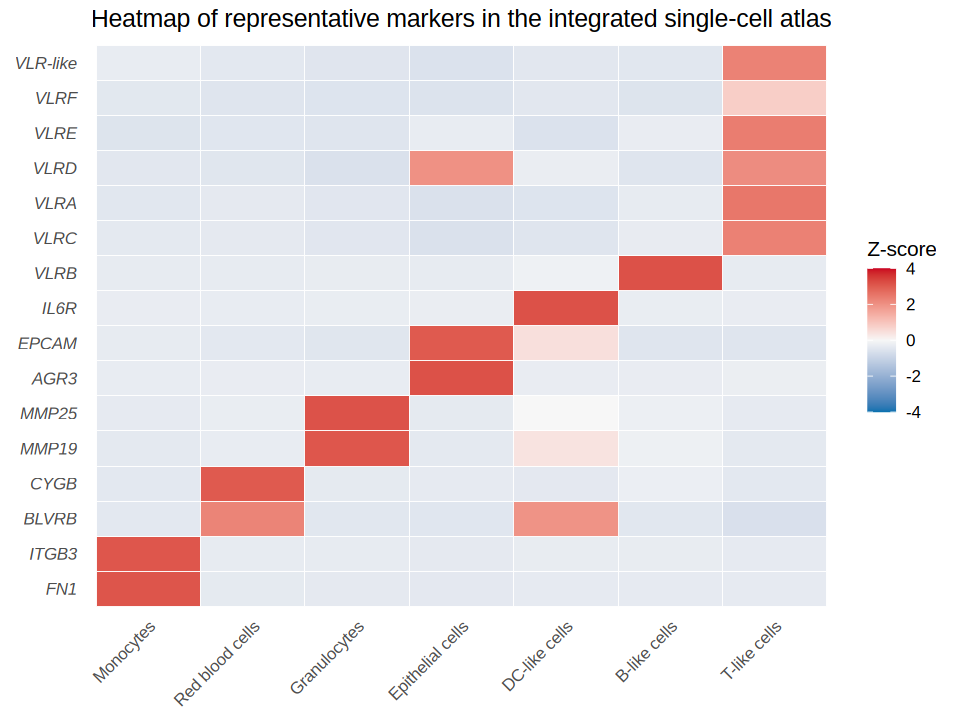

In [71]:
# 平均表达矩阵
exp_harmony <- AverageExpression(merge_sc_harmony, return.seurat = FALSE)$RNA
# 选择感兴趣的基因
genes_harmony <- names(cluster_markers_harmony)
sub_exp_harmony <- exp_harmony[genes_harmony, , drop = FALSE]
# Z-score 标准化
scaled_exp_harmony <- t(scale(t(sub_exp_harmony)))
# 行名加注释
rownames(scaled_exp_harmony) <- cluster_markers_harmony[rownames(scaled_exp_harmony)]

# 转换为 long dataframe
scaled_df_harmony <- as.data.frame(scaled_exp_harmony)
scaled_df_harmony$Gene <- rownames(scaled_df_harmony)
df_long_harmony <- melt(scaled_df_harmony, id.vars = "Gene", variable.name = "Celltype", value.name = "Zscore")

# 设置 Celltype 和 Gene 的显示顺序
desired_order_harmony <- c(
  "Monocytes", "Red blood cells", "Granulocytes","Epithelial cells",
  "DC-like cells","B-like cells", "T-like cells")
gene_order_harmony <- unname(cluster_markers_harmony)

df_long_harmony$Celltype <- factor(df_long_harmony$Celltype, levels = desired_order_harmony)
df_long_harmony$Gene <- factor(df_long_harmony$Gene, levels = gene_order_harmony)

df_long_harmony <- df_long_harmony[!is.na(df_long_harmony$Celltype), ]

# 设置颜色
my_colors_harmony <- scale_fill_gradient2(
  low = "#0571b0",  # 深蓝，对应 Z = -3
  mid = "#f7f7f7",  # 白色，对应 Z = 0
  high = "#ca0020", # 深红，对应 Z = +3
  midpoint = 0,
  limits = c(-4, 4), # 保持对称的视觉效果
  name = "Z-score"
)

# 作图
ggplot(df_long_harmony, aes(x = Celltype, y = Gene, fill = Zscore)) +
  geom_tile(color = "white", linewidth = 0.2) +
  my_colors_harmony +
  theme_minimal(base_size = 12) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1),
    axis.text.y = element_text(face = "italic"),
    panel.grid = element_blank(),
    plot.title = element_text(hjust = 0.5)
  ) +
  labs(title = "Heatmap of representative markers in the integrated single-cell atlas", x = NULL, y = NULL)

# 控制图像大小
options(repr.plot.width = 8, repr.plot.height = 6)

# Fig1d

In [72]:
p_blood_vlra <- FeaturePlot(blood_sc, features = c("nbisL1-mrna-15664")) +
  labs(title = "VLRA") +
  theme_void() +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    legend.position = "right"
  )
dir.create("/home/yating/VLR/blood", recursive = TRUE, showWarnings = FALSE)
ggsave("/home/yating/VLR/blood/blood_VLRA_featureplot.png", plot = p_blood_vlra, width = 4, height = 3.5, dpi = 300)

# VLRC
p_blood_vlrc <- FeaturePlot(blood_sc, features = c("nbisL1-mrna-8677")) +
  labs(title = "VLRC") +
  theme_void() +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    legend.position = "right"
  )
ggsave("/home/yating/VLR/blood/blood_VLRC_featureplot.png", plot = p_blood_vlrc, width = 4, height = 3.5, dpi = 300)

# VLRB
p_blood_vlrb <- FeaturePlot(blood_sc, features = c("MSTRG.4638")) +
  labs(title = "VLRB") +
  theme_void() +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    legend.position = "right"
  )
ggsave("/home/yating/VLR/blood/blood_VLRB_featureplot.png", plot = p_blood_vlrb, width = 4, height = 3.5, dpi = 300)

# VLR-like
p_blood_vlrlike <- FeaturePlot(blood_sc, features = c("MSTRG.4829")) +
  labs(title = "VLR-like") +
  theme_void() +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    legend.position = "right"
  )
ggsave("/home/yating/VLR/blood/blood_VLRlike_featureplot.png", plot = p_blood_vlrlike, width = 4, height = 3.5, dpi = 300)

# VLRD
p_blood_vlrd <- FeaturePlot(blood_sc, features = c("MSTRG.31304")) +
  labs(title = "VLRD") +
  theme_void() +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    legend.position = "right"
  )
ggsave("/home/yating/VLR/blood/blood_VLRD_featureplot.png", plot = p_blood_vlrd, width = 4, height = 3.5, dpi = 300)

# VLRE
p_blood_vlre <- FeaturePlot(blood_sc, features = c("MSTRG.31308")) +
  labs(title = "VLRE") +
  theme_void() +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    legend.position = "right"
  )
ggsave("/home/yating/VLR/blood/blood_VLRE_featureplot.png", plot = p_blood_vlre, width = 4, height = 3.5, dpi = 300)

# VLRF
p_blood_vlrf <- FeaturePlot(blood_sc, features = c("nbisL1-mrna-15650")) +
  labs(title = "VLRF") +
  theme_void() +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    legend.position = "right"
  )
ggsave("/home/yating/VLR/blood/blood_VLRF_featureplot.png", plot = p_blood_vlrf, width = 4, height = 3.5, dpi = 300)

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



In [16]:
p_gill_vlra <- FeaturePlot(gill_sc, features = c("nbisL1-mrna-15664")) +
  labs(title = "VLRA") +
  theme_void() +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    legend.position = "right"
  )
dir.create("/home/yating/VLR/gill", recursive = TRUE, showWarnings = FALSE)
ggsave("/home/yating/VLR/gill/gill_VLRA_featureplot.png", plot = p_gill_vlra, width = 4, height = 3.5, dpi = 300)

# VLRC
p_gill_vlrc <- FeaturePlot(gill_sc, features = c("nbisL1-mrna-8677")) +
  labs(title = "VLRC") +
  theme_void() +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    legend.position = "right"
  )
ggsave("/home/yating/VLR/gill/gill_VLRC_featureplot.png", plot = p_gill_vlrc, width = 4, height = 3.5, dpi = 300)

# VLRB
p_gill_vlrb <- FeaturePlot(gill_sc, features = c("MSTRG.4638")) +
  labs(title = "VLRB") +
  theme_void() +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    legend.position = "right"
  )
ggsave("/home/yating/VLR/gill/gill_VLRB_featureplot.png", plot = p_gill_vlrb, width = 4, height = 3.5, dpi = 300)

# VLR-like
p_gill_vlrlike <- FeaturePlot(gill_sc, features = c("MSTRG.4829")) +
  labs(title = "VLR-like") +
  theme_void() +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    legend.position = "right"
  )
ggsave("/home/yating/VLR/gill/gill_VLRlike_featureplot.png", plot = p_gill_vlrlike, width = 4, height = 3.5, dpi = 300)

# VLRD
p_gill_vlrd <- FeaturePlot(gill_sc, features = c("MSTRG.31304")) +
  labs(title = "VLRD") +
  theme_void() +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    legend.position = "right"
  )
ggsave("/home/yating/VLR/gill/gill_VLRD_featureplot.png", plot = p_gill_vlrd, width = 4, height = 3.5, dpi = 300)

# VLRE
p_gill_vlre <- FeaturePlot(gill_sc, features = c("MSTRG.31308")) +
  labs(title = "VLRE") +
  theme_void() +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    legend.position = "right"
  )
ggsave("/home/yating/VLR/gill/gill_VLRE_featureplot.png", plot = p_gill_vlre, width = 4, height = 3.5, dpi = 300)

# VLRF
p_gill_vlrf <- FeaturePlot(gill_sc, features = c("nbisL1-mrna-15650")) +
  labs(title = "VLRF") +
  theme_void() +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    legend.position = "right"
  )
ggsave("/home/yating/VLR/gill/gill_VLRF_featureplot.png", plot = p_gill_vlrf, width = 4, height = 3.5, dpi = 300)

In [73]:
p_intestine_vlra <- FeaturePlot(intestine_sc, features = c("nbisL1-mrna-15664")) +
  labs(title = "VLRA") +
  theme_void() +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    legend.position = "right"
  )
dir.create("/home/yating/VLR/intestine", recursive = TRUE, showWarnings = FALSE)
ggsave("/home/yating/VLR/intestine/intestine_VLRA_featureplot.png", plot = p_intestine_vlra, width = 4, height = 3.5, dpi = 300)

# VLRC
p_intestine_vlrc <- FeaturePlot(intestine_sc, features = c("nbisL1-mrna-8677")) +
  labs(title = "VLRC") +
  theme_void() +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    legend.position = "right"
  )
ggsave("/home/yating/VLR/intestine/intestine_VLRC_featureplot.png", plot = p_intestine_vlrc, width = 4, height = 3.5, dpi = 300)

# VLRB
p_intestine_vlrb <- FeaturePlot(intestine_sc, features = c("MSTRG.4638")) +
  labs(title = "VLRB") +
  theme_void() +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    legend.position = "right"
  )
ggsave("/home/yating/VLR/intestine/intestine_VLRB_featureplot.png", plot = p_intestine_vlrb, width = 4, height = 3.5, dpi = 300)

# VLR-like
p_intestine_vlrlike <- FeaturePlot(intestine_sc, features = c("MSTRG.4829")) +
  labs(title = "VLR-like") +
  theme_void() +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    legend.position = "right"
  )
ggsave("/home/yating/VLR/intestine/intestine_VLRlike_featureplot.png", plot = p_intestine_vlrlike, width = 4, height = 3.5, dpi = 300)

# VLRD
p_intestine_vlrd <- FeaturePlot(intestine_sc, features = c("MSTRG.31304")) +
  labs(title = "VLRD") +
  theme_void() +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    legend.position = "right"
  )
ggsave("/home/yating/VLR/intestine/intestine_VLRD_featureplot.png", plot = p_intestine_vlrd, width = 4, height = 3.5, dpi = 300)

# VLRE
p_intestine_vlre <- FeaturePlot(intestine_sc, features = c("MSTRG.31308")) +
  labs(title = "VLRE") +
  theme_void() +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    legend.position = "right"
  )
ggsave("/home/yating/VLR/intestine/intestine_VLRE_featureplot.png", plot = p_intestine_vlre, width = 4, height = 3.5, dpi = 300)

# VLRF
p_intestine_vlrf <- FeaturePlot(intestine_sc, features = c("nbisL1-mrna-15650")) +
  labs(title = "VLRF") +
  theme_void() +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    legend.position = "right"
  )
ggsave("/home/yating/VLR/intestine/intestine_VLRF_featureplot.png", plot = p_intestine_vlrf, width = 4, height = 3.5, dpi = 300)

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



# FigS1c-e

Blood

In [74]:
cluster_markers_blood <- c(
    "MSTRG.3386" = "GRN",
     "MSTRG.8828" = "TLR7",
    "MSTRG.25883" = "HAAF",
    "nbisL1-mrna-4499" = "MMP19",
    "MSTRG.22455" = "FN1",
    "MSTRG.6734" = "ITGB3",
    "MSTRG.961" = "glob1",
    "nbisL1-mrna-403" = "CYGB",
     # VLR
  "MSTRG.4638" = "VLRB",
  "nbisL1-mrna-8677" = "VLRC",
  "nbisL1-mrna-15664" = "VLRA",
    "MSTRG.31304" = "VLRD",
  "MSTRG.31308" = "VLRE",
  "nbisL1-mrna-15650" = "VLRF",
    "MSTRG.4829" = "VLR-like")

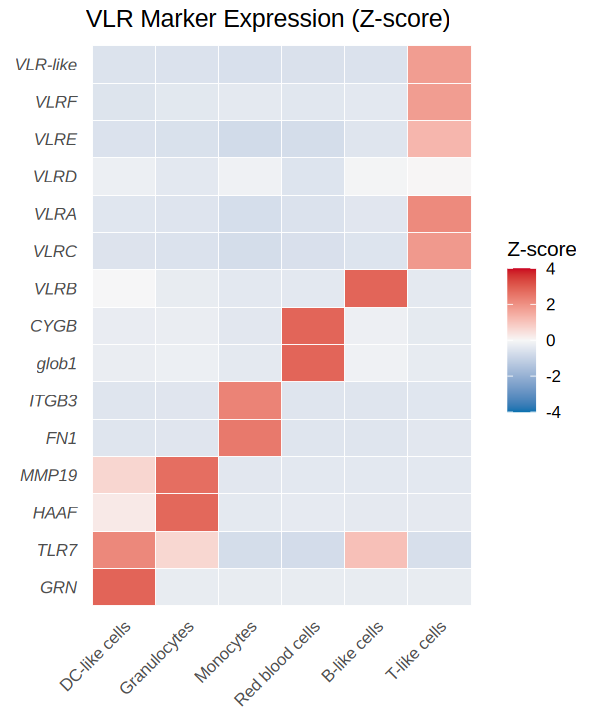

In [83]:
# 设置身份为 newcell1_blood
Idents(blood_sc) <- "custom_celltype"

# 计算表达矩阵
blood_exp <- AverageExpression(blood_sc, return.seurat = FALSE)$RNA

# 选择感兴趣的基因
genes_blood <- names(cluster_markers_blood)
blood_sub_exp <- blood_exp[genes_blood, , drop = FALSE]

# Z-score标准化
blood_scaled_exp <- t(scale(t(blood_sub_exp)))

# 重命名行为 marker 基因名
rownames(blood_scaled_exp) <- cluster_markers_blood[rownames(blood_scaled_exp)]

# 将 matrix 转换成 long dataframe
blood_scaled_df <- as.data.frame(blood_scaled_exp)
blood_scaled_df$Gene <- rownames(blood_scaled_df)
df_long_blood <- melt(blood_scaled_df, id.vars = "Gene", variable.name = "Celltype", value.name = "Zscore")

# 自定义 celltype 顺序（VLRC和VLRB 放最后）
desired_order_blood <- c(
   "DC-like cells", "Granulocytes", "Monocytes", "Red blood cells","B-like cells", "T-like cells")
gene_order_blood <- unname(cluster_markers_blood)

# 设置 Celltype 和 Gene 为因子，保持顺序
df_long_blood$Celltype <- factor(df_long_blood$Celltype, levels = desired_order_blood)
df_long_blood$Gene <- factor(df_long_blood$Gene, levels = gene_order_blood)
df_long_blood <- df_long_blood[!is.na(df_long_blood$Celltype), ]
# 设置颜色映射（与原图一致）
my_colors_blood <- scale_fill_gradient2(
  low = "#0571b0",     # 深蓝
  mid = "#f7f7f7",     # 中性
  high = "#ca0020",    # 深红
  midpoint = 0,
  limits = c(-4, 4),
  name = "Z-score"
)

# 绘图
ggplot(df_long_blood, aes(x = Celltype, y = Gene, fill = Zscore)) +
  geom_tile(color = "white", linewidth = 0.2) +
  my_colors_blood +
  theme_minimal(base_size = 12) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1),
    axis.text.y = element_text(face = "italic"),
    panel.grid = element_blank(),
    axis.title = element_blank()
  ) +
  labs(title = "VLR Marker Expression (Z-score)", x = NULL, y = NULL)

# 控制图大小
options(repr.plot.width = 5, repr.plot.height = 6)

Gill

In [76]:
Idents(gill_sc) <- "custom_celltype"

In [77]:
gill.exp <- AverageExpression(gill_sc, return.seurat = FALSE)$RNA

In [78]:
cluster_markers_gill <- c(
    "MSTRG.964" = "CYGB",
    "MSTRG.963" = "glob1",
    "MSTRG.5275" = "AGR3",
    "MSTRG.3738" = "S100A4",
    "MSTRG.25883" = "HAAF",
    "MSTRG.24553" = "LIP",
    "MSTRG.16655" = "IL6R",
    "nbisL1-mrna-4346" = "C1QTNF9",
    "nbisL1-mrna-10278" = "SIGLEC1",
    # VLR
  "MSTRG.4638" = "VLRB",
  "nbisL1-mrna-8677" = "VLRC",
  "nbisL1-mrna-15664" = "VLRA",
    "MSTRG.31304" = "VLRD",
  "MSTRG.31308" = "VLRE",
  "nbisL1-mrna-15650" = "VLRF",
    "MSTRG.4829" = "VLR-like")

In [79]:
# 选择感兴趣的基因
genes <- names(cluster_markers_gill)
gill_sub_exp <- gill.exp[genes, , drop = FALSE]

In [80]:
gill_scaled_exp <- t(scale(t(gill_sub_exp)))

In [81]:
rownames(gill_scaled_exp) <- cluster_markers_gill[rownames(gill_scaled_exp)]

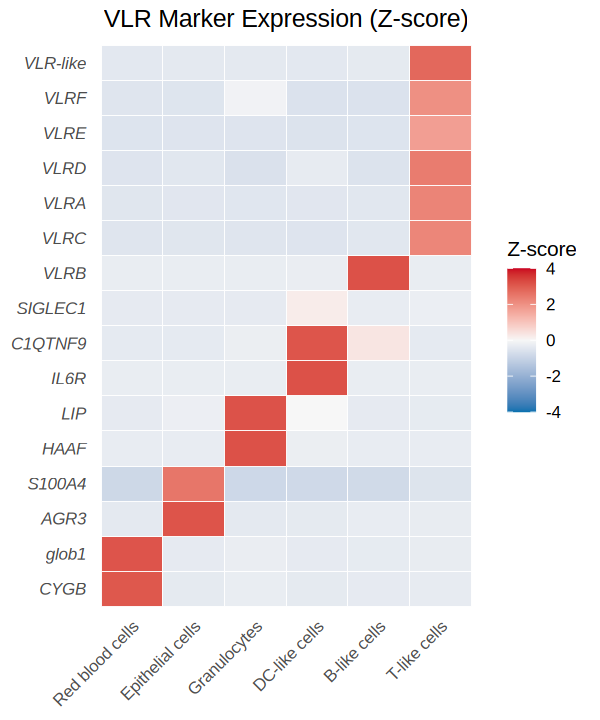

In [82]:
# 将 matrix 转换成 long dataframe
gill_scaled_df <- as.data.frame(gill_scaled_exp)
gill_scaled_df$Gene <- rownames(gill_scaled_df)
df_long_gill <- melt(gill_scaled_df, id.vars = "Gene", variable.name = "Celltype", value.name = "Zscore")

# 你希望的 celltype 顺序（把 VLRC 和 VLRB 放最后）
desired_order <- c(
  "Red blood cells", "Epithelial cells", 
  "Granulocytes", "DC-like cells", "B-like cells","T-like cells" )
gene_order <- unname(cluster_markers_gill)  # 提取 value（即 CYGB, VLRC, etc.）保持顺序

# 转换为有序因子
df_long_gill$Celltype <- factor(df_long_gill$Celltype, levels = desired_order)
df_long_gill$Gene <- factor(df_long_gill$Gene, levels = gene_order)
df_long_gill <- df_long_gill[!is.na(df_long_gill$Celltype), ]

# 设置颜色映射，与原图相似
my_colors <- scale_fill_gradient2(
  low = "#0571b0",   # 深蓝，对应 Z=-3
  mid = "#f7f7f7",   # 白色，对应 Z=0
  high = "#ca0020",  # 深红，对应 Z=+3
  midpoint = 0,
  limits = c(-4, 4), # 保持对称的视觉效果
  name = "Z-score"
)

# 绘图
ggplot(df_long_gill, aes(x = Celltype, y = Gene, fill = Zscore)) +
  geom_tile(color = "white", linewidth = 0.2) +
  my_colors +
  theme_minimal(base_size = 12) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1),
    axis.text.y = element_text(face = "italic"),
    panel.grid = element_blank(),
    plot.title = element_text(hjust = 0.5)
  ) +
  labs(title = "VLR Marker Expression (Z-score)", x = NULL, y = NULL)
options(repr.plot.width = 5, repr.plot.height = 6)

Intestine

In [84]:
cluster_markers_intestine <- c(
    "MSTRG.2637" = "RIBC2",
    "MSTRG.11055" = "CDHR3",
    "MSTRG.5275" = "AGR3",
    "nbisL1-mrna-4499" = "MMP19",
    "MSTRG.25883" = "HAAF",
    "MSTRG.6798" = "IL8",
    "MSTRG.21086" = "IL1B",
    "MSTRG.990" = "GLOB1",
    "nbisL1-mrna-403" = "CYGB",
       # VLR
  "MSTRG.4638" = "VLRB",
  "nbisL1-mrna-8677" = "VLRC",
  "nbisL1-mrna-15664" = "VLRA",
    "MSTRG.31304" = "VLRD",
  "MSTRG.31308" = "VLRE",
  "nbisL1-mrna-15650" = "VLRF",
    "MSTRG.4829" = "VLR-like")

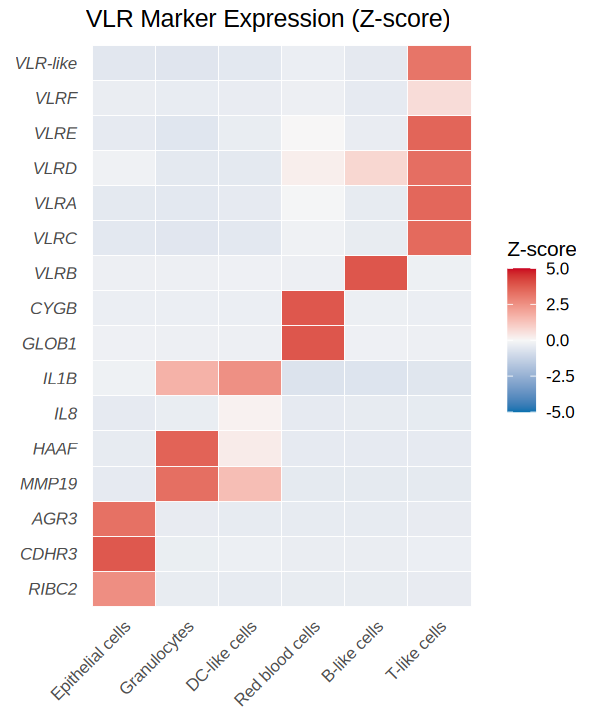

In [85]:
# 设置身份为 newcell1_intestine
Idents(intestine_sc) <- "custom_celltype"

# 计算表达矩阵
intestine_exp <- AverageExpression(intestine_sc, return.seurat = FALSE)$RNA

# 选择感兴趣的基因
genes_intestine <- names(cluster_markers_intestine)
intestine_sub_exp <- intestine_exp[genes_intestine, , drop = FALSE]

# Z-score 标准化
intestine_scaled_exp <- t(scale(t(intestine_sub_exp)))

# 重命名行为 marker 基因名
rownames(intestine_scaled_exp) <- cluster_markers_intestine[rownames(intestine_scaled_exp)]

# 将 matrix 转换为 long dataframe
intestine_scaled_df <- as.data.frame(intestine_scaled_exp)
intestine_scaled_df$Gene <- rownames(intestine_scaled_df)
df_long_intestine <- melt(intestine_scaled_df, id.vars = "Gene", variable.name = "Celltype", value.name = "Zscore")

# 设置细胞类型顺序，按图例顺序
desired_order_intestine <- c(
  "Epithelial cells","Granulocytes", "DC-like cells",
  "Red blood cells", "B-like cells","T-like cells")
gene_order_intestine <- unname(cluster_markers_intestine)

# 设置 Celltype 和 Gene 为因子，保持顺序
df_long_intestine$Celltype <- factor(df_long_intestine$Celltype, levels = desired_order_intestine)
df_long_intestine$Gene <- factor(df_long_intestine$Gene, levels = gene_order_intestine)
df_long_intestine <- df_long_intestine[!is.na(df_long_intestine$Celltype), ]
# 设置颜色映射
my_colors_intestine <- scale_fill_gradient2(
  low = "#0571b0",     # 深蓝
  mid = "#f7f7f7",     # 中性
  high = "#ca0020",    # 深红
  midpoint = 0,
  limits = c(-5, 5),
  name = "Z-score"
)

# 绘图
ggplot(df_long_intestine, aes(x = Celltype, y = Gene, fill = Zscore)) +
  geom_tile(color = "white", linewidth = 0.2) +
  my_colors_intestine +
  theme_minimal(base_size = 12) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1),
    axis.text.y = element_text(face = "italic"),
    panel.grid = element_blank(),
    axis.title = element_blank()
  ) +
  labs(title = "VLR Marker Expression (Z-score)", x = NULL, y = NULL)

# 控制图大小
options(repr.plot.width = 5, repr.plot.height = 6)

# FigureS3

blood

In [86]:
# 只保留 blood 和 intestine 的 B-like cells
bcell_blood <- subset(
  blood_sc,
  subset = newcell == "B-like cells" )

    marker n_double_positive     fraction rowlab
1     VLRA                24 1.150638e-03   VLRB
2     VLRC                36 1.725956e-03   VLRB
3     VLRD                 0 0.000000e+00   VLRB
4     VLRE                 1 4.794324e-05   VLRB
5     VLRF                 0 0.000000e+00   VLRB
6 VLR-like                 4 1.917729e-04   VLRB


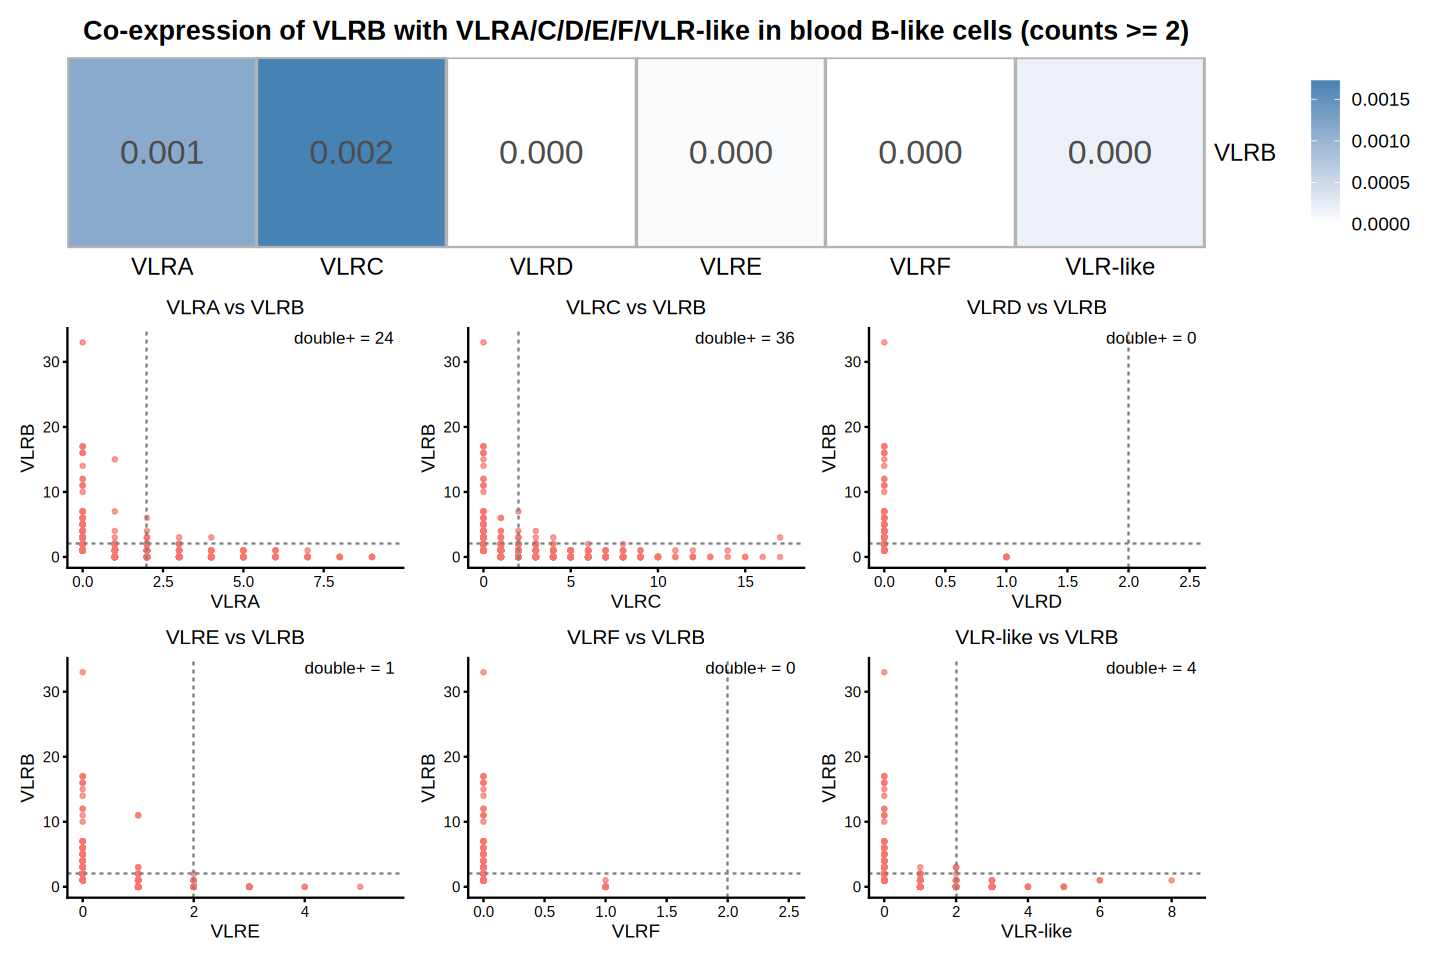

In [88]:
library(Seurat)
library(patchwork)
library(ggplot2)

cutoff <- 2
obj <- bcell_blood
tissue_label <- "blood"

gene_map <- c(
  VLRA       = "nbisL1-mrna-15664",
  VLRC       = "nbisL1-mrna-8677",
  VLRD       = "MSTRG.31304",
  VLRE       = "MSTRG.31308",
  VLRF       = "nbisL1-mrna-15650",
  "VLR-like" = "MSTRG.4829",
  VLRB       = "MSTRG.4638"
)

markers <- c("VLRA", "VLRC", "VLRD", "VLRE", "VLRF", "VLR-like")
vlrb_gene <- unname(gene_map["VLRB"])

# -------- robust counts extraction --------
count_mat <- tryCatch(
  GetAssayData(obj, assay = DefaultAssay(obj), layer = "counts"),
  error = function(e) GetAssayData(obj, assay = DefaultAssay(obj), slot = "counts")
)

# 1. Heatmap data
# -------------------------
heat_df <- do.call(rbind, lapply(markers, function(mk) {
  gene_id <- unname(gene_map[mk])
  x_vec <- as.numeric(count_mat[gene_id, ])
  y_vec <- as.numeric(count_mat[vlrb_gene, ])

  n_dp <- sum(x_vec >= cutoff & y_vec >= cutoff)
  frac_dp <- mean(x_vec >= cutoff & y_vec >= cutoff)

  data.frame(
    marker = mk,
    n_double_positive = n_dp,
    fraction = frac_dp,
    stringsAsFactors = FALSE
  )
}))

heat_df$marker <- factor(heat_df$marker, levels = markers)
heat_df$rowlab <- "VLRB"

print(heat_df)

# -------------------------
# 2. Heatmap plot
# -------------------------
max_fill <- max(heat_df$fraction)

if (max_fill == 0) {
  p_heat <- ggplot(heat_df, aes(x = marker, y = rowlab)) +
    geom_tile(fill = "white", color = "grey70", linewidth = 0.7) +
    geom_text(aes(label = sprintf("%.3f", fraction)), size = 7, color = "grey30") +
    scale_x_discrete(expand = c(0, 0)) +
    scale_y_discrete(position = "right", expand = c(0, 0)) +
    labs(
      title = paste0(
        "Co-expression of VLRB with VLRA/C/D/E/F/VLR-like in ",
        tissue_label, " B-like cells (counts >= ", cutoff, ")"
      ),
      x = NULL,
      y = NULL
    ) +
    theme_minimal(base_size = 14) +
    theme(
      panel.grid = element_blank(),
      panel.border = element_blank(),
      axis.line = element_blank(),
      axis.ticks = element_blank(),
      axis.text.x = element_text(size = 14, color = "black"),
      axis.text.y = element_text(size = 14, color = "black"),
      plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
      legend.position = "none"
    )
} else {
  p_heat <- ggplot(heat_df, aes(x = marker, y = rowlab, fill = fraction)) +
    geom_tile(color = "grey70", linewidth = 0.7) +
    geom_text(aes(label = sprintf("%.3f", fraction)), size = 7, color = "grey30") +
    scale_x_discrete(expand = c(0, 0)) +
    scale_y_discrete(position = "right", expand = c(0, 0)) +
    scale_fill_gradient(
      low = "white",
      high = "steelblue",
      limits = c(0, max_fill),
      breaks = pretty(c(0, max_fill), n = 4),
      name = NULL
    ) +
    labs(
      title = paste0(
        "Co-expression of VLRB with VLRA/C/D/E/F/VLR-like in ",
        tissue_label, " B-like cells (counts >= ", cutoff, ")"
      ),
      x = NULL,
      y = NULL
    ) +
    theme_minimal(base_size = 14) +
    theme(
      panel.grid = element_blank(),
      panel.border = element_blank(),
      axis.line = element_blank(),
      axis.ticks = element_blank(),
      axis.text.x = element_text(size = 14, color = "black"),
      axis.text.y = element_text(size = 14, color = "black"),
      plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
      legend.title = element_blank()
    )
}



# -------------------------
# 2. Scatter plots
# -------------------------
p_list <- lapply(markers, function(mk) {
  gene_id  <- unname(gene_map[mk])
  gene_lab <- mk

  x_vec <- as.numeric(count_mat[gene_id, ])
  y_vec <- as.numeric(count_mat[vlrb_gene, ])

  # 为了避免全是(0,0)把图挤爆，只保留至少一个基因>0的细胞
  df_plot <- data.frame(
    x = x_vec,
    y = y_vec
  )
  df_plot <- df_plot[df_plot$x > 0 | df_plot$y > 0, , drop = FALSE]

  n_dp <- sum(x_vec >= cutoff & y_vec >= cutoff)

  if (nrow(df_plot) == 0) {
    return(
      ggplot() +
        annotate(
          "text",
          x = 0.5, y = 0.5,
          label = paste0(gene_lab, " vs VLRB\nNo cells with nonzero expression")
        ) +
        theme_void() +
        labs(title = paste0(gene_lab, " vs VLRB"))
    )
  }

  xmax <- max(df_plot$x, cutoff)
  ymax <- max(df_plot$y, cutoff)

  ggplot(df_plot, aes(x = x, y = y)) +
    geom_point(size = 0.8, alpha = 0.7, color = "#F8766D") +
    geom_vline(xintercept = cutoff, linetype = "dashed", color = "grey50") +
    geom_hline(yintercept = cutoff, linetype = "dashed", color = "grey50") +
    annotate(
      "text",
      x = Inf, y = Inf,
      label = paste0("double+ = ", n_dp),
      hjust = 1.1, vjust = 1.3, size = 3.5
    ) +
    coord_cartesian(
      xlim = c(0, xmax + 0.5),
      ylim = c(0, ymax + 0.5)
    ) +
    labs(
      x = gene_lab,
      y = "VLRB",
      title = paste0(gene_lab, " vs VLRB")
    ) +
    theme_classic() +
    theme(
      plot.title = element_text(hjust = 0.5, size = 12),
      axis.title = element_text(size = 11),
      legend.position = "none"
    )
})

p_scatter <- wrap_plots(p_list, ncol = 3) +
  plot_annotation(
    title = paste0(
      "Co-expression scatter plots of VLRA/C/D/E/F/VLR-like with VLRB in ",
      tissue_label, " B-like cells (cutoff = ", cutoff, ")"
    )
  )

# -------------------------
# 3. Show together
# -------------------------
p_heat / p_scatter + plot_layout(heights = c(1, 3))

options(repr.plot.width = 12, repr.plot.height = 8)

intestine

In [89]:
# 只保留 blood 和 intestine 的 B-like cells
bcell_intestine <- subset(
  intestine_sc,
  subset = newcell == "B-like cells" )

    marker n_double_positive     fraction rowlab
1     VLRA                 1 0.0003356831   VLRB
2     VLRC                 4 0.0013427325   VLRB
3     VLRD                 0 0.0000000000   VLRB
4     VLRE                 1 0.0003356831   VLRB
5     VLRF                 0 0.0000000000   VLRB
6 VLR-like                 0 0.0000000000   VLRB


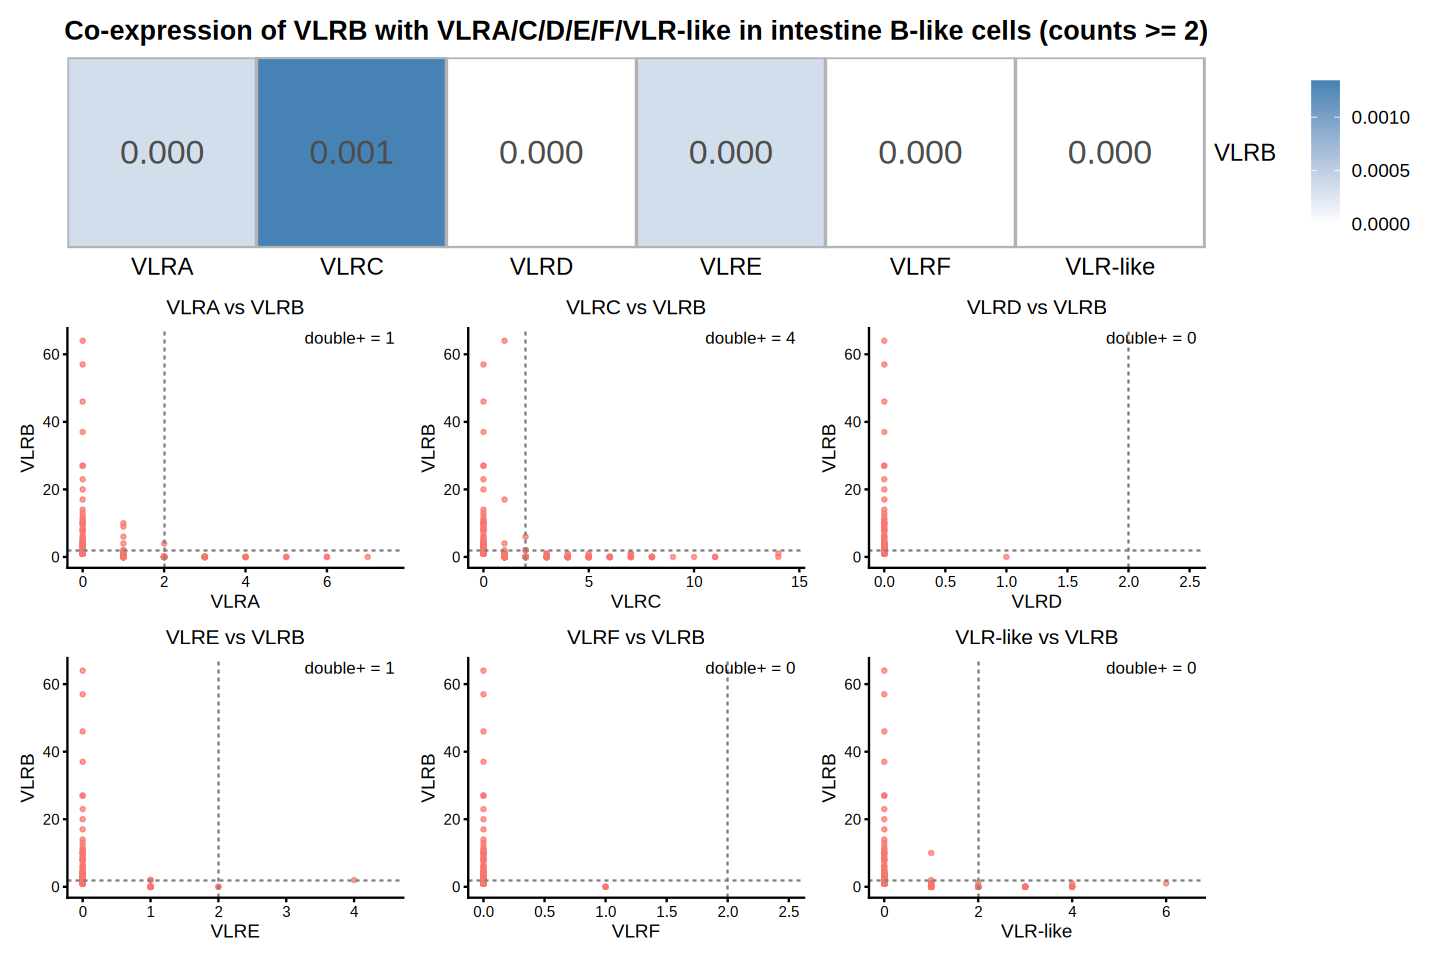

In [90]:
library(Seurat)
library(patchwork)
library(ggplot2)

cutoff <- 2
obj <- bcell_intestine
tissue_label <- "intestine"

gene_map <- c(
  VLRA       = "nbisL1-mrna-15664",
  VLRC       = "nbisL1-mrna-8677",
  VLRD       = "MSTRG.31304",
  VLRE       = "MSTRG.31308",
  VLRF       = "nbisL1-mrna-15650",
  "VLR-like" = "MSTRG.4829",
  VLRB       = "MSTRG.4638"
)

markers <- c("VLRA", "VLRC", "VLRD", "VLRE", "VLRF", "VLR-like")
vlrb_gene <- unname(gene_map["VLRB"])

# -------- robust counts extraction --------
count_mat <- tryCatch(
  GetAssayData(obj, assay = DefaultAssay(obj), layer = "counts"),
  error = function(e) GetAssayData(obj, assay = DefaultAssay(obj), slot = "counts")
)

# 1. Heatmap data
# -------------------------
heat_df <- do.call(rbind, lapply(markers, function(mk) {
  gene_id <- unname(gene_map[mk])
  x_vec <- as.numeric(count_mat[gene_id, ])
  y_vec <- as.numeric(count_mat[vlrb_gene, ])

  n_dp <- sum(x_vec >= cutoff & y_vec >= cutoff)
  frac_dp <- mean(x_vec >= cutoff & y_vec >= cutoff)

  data.frame(
    marker = mk,
    n_double_positive = n_dp,
    fraction = frac_dp,
    stringsAsFactors = FALSE
  )
}))

heat_df$marker <- factor(heat_df$marker, levels = markers)
heat_df$rowlab <- "VLRB"

print(heat_df)

# -------------------------
# 2. Heatmap plot
# -------------------------
max_fill <- max(heat_df$fraction)

if (max_fill == 0) {
  p_heat <- ggplot(heat_df, aes(x = marker, y = rowlab)) +
    geom_tile(fill = "white", color = "grey70", linewidth = 0.7) +
    geom_text(aes(label = sprintf("%.3f", fraction)), size = 7, color = "grey30") +
    scale_x_discrete(expand = c(0, 0)) +
    scale_y_discrete(position = "right", expand = c(0, 0)) +
    labs(
      title = paste0(
        "Co-expression of VLRB with VLRA/C/D/E/F/VLR-like in ",
        tissue_label, " B-like cells (counts >= ", cutoff, ")"
      ),
      x = NULL,
      y = NULL
    ) +
    theme_minimal(base_size = 14) +
    theme(
      panel.grid = element_blank(),
      panel.border = element_blank(),
      axis.line = element_blank(),
      axis.ticks = element_blank(),
      axis.text.x = element_text(size = 14, color = "black"),
      axis.text.y = element_text(size = 14, color = "black"),
      plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
      legend.position = "none"
    )
} else {
  p_heat <- ggplot(heat_df, aes(x = marker, y = rowlab, fill = fraction)) +
    geom_tile(color = "grey70", linewidth = 0.7) +
    geom_text(aes(label = sprintf("%.3f", fraction)), size = 7, color = "grey30") +
    scale_x_discrete(expand = c(0, 0)) +
    scale_y_discrete(position = "right", expand = c(0, 0)) +
    scale_fill_gradient(
      low = "white",
      high = "steelblue",
      limits = c(0, max_fill),
      breaks = pretty(c(0, max_fill), n = 4),
      name = NULL
    ) +
    labs(
      title = paste0(
        "Co-expression of VLRB with VLRA/C/D/E/F/VLR-like in ",
        tissue_label, " B-like cells (counts >= ", cutoff, ")"
      ),
      x = NULL,
      y = NULL
    ) +
    theme_minimal(base_size = 14) +
    theme(
      panel.grid = element_blank(),
      panel.border = element_blank(),
      axis.line = element_blank(),
      axis.ticks = element_blank(),
      axis.text.x = element_text(size = 14, color = "black"),
      axis.text.y = element_text(size = 14, color = "black"),
      plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
      legend.title = element_blank()
    )
}


# -------------------------
# 2. Scatter plots
# -------------------------
p_list <- lapply(markers, function(mk) {
  gene_id  <- unname(gene_map[mk])
  gene_lab <- mk

  x_vec <- as.numeric(count_mat[gene_id, ])
  y_vec <- as.numeric(count_mat[vlrb_gene, ])

  # 为了避免全是(0,0)把图挤爆，只保留至少一个基因>0的细胞
  df_plot <- data.frame(
    x = x_vec,
    y = y_vec
  )
  df_plot <- df_plot[df_plot$x > 0 | df_plot$y > 0, , drop = FALSE]

  n_dp <- sum(x_vec >= cutoff & y_vec >= cutoff)

  if (nrow(df_plot) == 0) {
    return(
      ggplot() +
        annotate(
          "text",
          x = 0.5, y = 0.5,
          label = paste0(gene_lab, " vs VLRB\nNo cells with nonzero expression")
        ) +
        theme_void() +
        labs(title = paste0(gene_lab, " vs VLRB"))
    )
  }

  xmax <- max(df_plot$x, cutoff)
  ymax <- max(df_plot$y, cutoff)

  ggplot(df_plot, aes(x = x, y = y)) +
    geom_point(size = 0.8, alpha = 0.7, color = "#F8766D") +
    geom_vline(xintercept = cutoff, linetype = "dashed", color = "grey50") +
    geom_hline(yintercept = cutoff, linetype = "dashed", color = "grey50") +
    annotate(
      "text",
      x = Inf, y = Inf,
      label = paste0("double+ = ", n_dp),
      hjust = 1.1, vjust = 1.3, size = 3.5
    ) +
    coord_cartesian(
      xlim = c(0, xmax + 0.5),
      ylim = c(0, ymax + 0.5)
    ) +
    labs(
      x = gene_lab,
      y = "VLRB",
      title = paste0(gene_lab, " vs VLRB")
    ) +
    theme_classic() +
    theme(
      plot.title = element_text(hjust = 0.5, size = 12),
      axis.title = element_text(size = 11),
      legend.position = "none"
    )
})

p_scatter <- wrap_plots(p_list, ncol = 3) +
  plot_annotation(
    title = paste0(
      "Co-expression scatter plots of VLRA/C/D/E/F/VLR-like with VLRB in ",
      tissue_label, " B-like cells (cutoff = ", cutoff, ")"
    )
  )

# -------------------------
# 3. Show together
# -------------------------
p_heat / p_scatter + plot_layout(heights = c(1, 3))

options(repr.plot.width = 10, repr.plot.height = 8)

gill

In [91]:
# 只保留 blood 和 intestine 的 B-like cells
bcell_gill <- subset(
  gill_sc,
  subset = newcell == "B-like cells" )

    marker n_double_positive fraction rowlab
1     VLRA                 0        0   VLRB
2     VLRC                 0        0   VLRB
3     VLRD                 0        0   VLRB
4     VLRE                 0        0   VLRB
5     VLRF                 0        0   VLRB
6 VLR-like                 0        0   VLRB


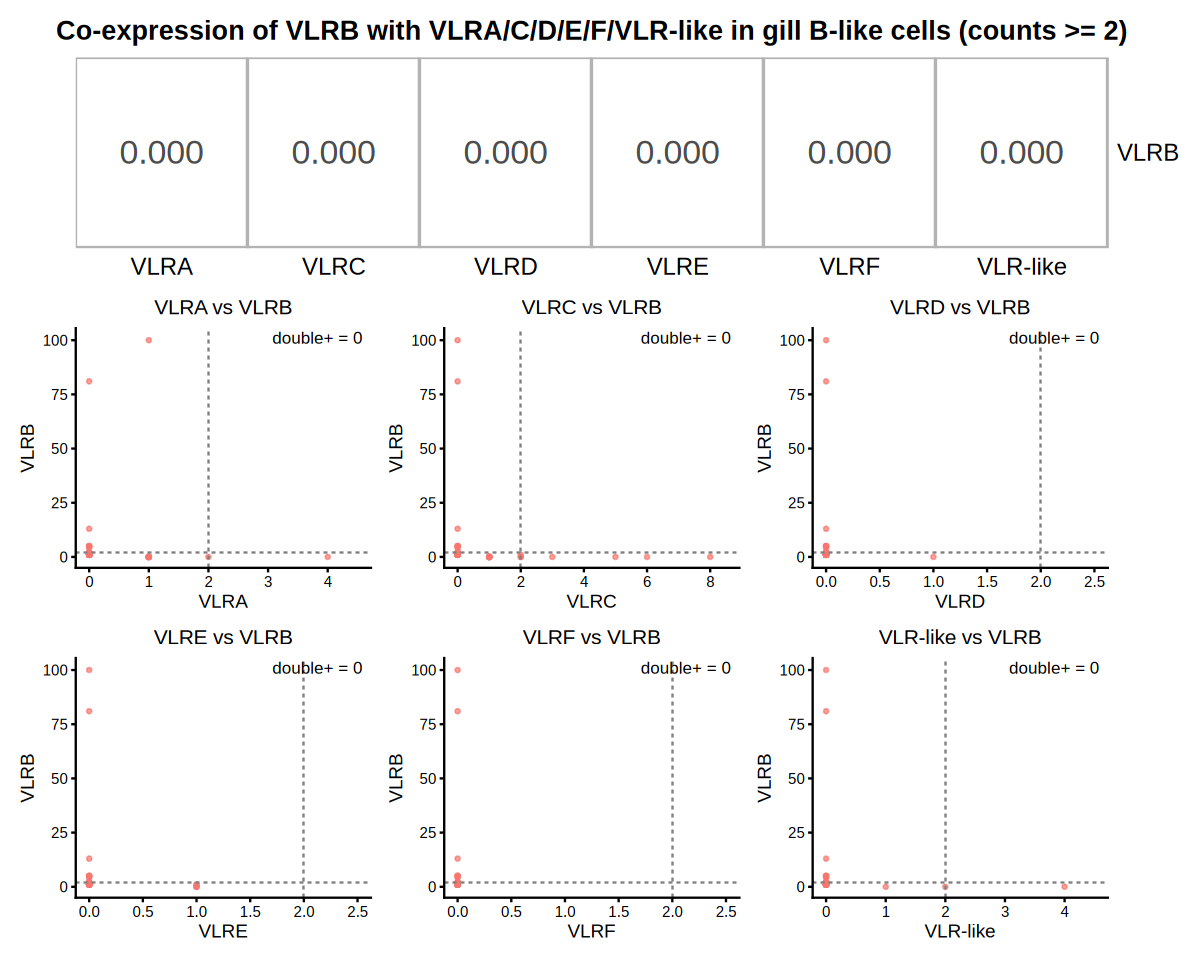

In [92]:
library(Seurat)
library(patchwork)
library(ggplot2)

cutoff <- 2
obj <- bcell_gill
tissue_label <- "gill"

gene_map <- c(
  VLRA       = "nbisL1-mrna-15664",
  VLRC       = "nbisL1-mrna-8677",
  VLRD       = "MSTRG.31304",
  VLRE       = "MSTRG.31308",
  VLRF       = "nbisL1-mrna-15650",
  "VLR-like" = "MSTRG.4829",
  VLRB       = "MSTRG.4638"
)

markers <- c("VLRA", "VLRC", "VLRD", "VLRE", "VLRF", "VLR-like")
vlrb_gene <- unname(gene_map["VLRB"])

# -------- robust counts extraction --------
count_mat <- tryCatch(
  GetAssayData(obj, assay = DefaultAssay(obj), layer = "counts"),
  error = function(e) GetAssayData(obj, assay = DefaultAssay(obj), slot = "counts")
)

# 1. Heatmap data
# -------------------------
heat_df <- do.call(rbind, lapply(markers, function(mk) {
  gene_id <- unname(gene_map[mk])
  x_vec <- as.numeric(count_mat[gene_id, ])
  y_vec <- as.numeric(count_mat[vlrb_gene, ])

  n_dp <- sum(x_vec >= cutoff & y_vec >= cutoff)
  frac_dp <- mean(x_vec >= cutoff & y_vec >= cutoff)

  data.frame(
    marker = mk,
    n_double_positive = n_dp,
    fraction = frac_dp,
    stringsAsFactors = FALSE
  )
}))

heat_df$marker <- factor(heat_df$marker, levels = markers)
heat_df$rowlab <- "VLRB"

print(heat_df)

# -------------------------
# 2. Heatmap plot
# -------------------------
max_fill <- max(heat_df$fraction)

if (max_fill == 0) {
  p_heat <- ggplot(heat_df, aes(x = marker, y = rowlab)) +
    geom_tile(fill = "white", color = "grey70", linewidth = 0.7) +
    geom_text(aes(label = sprintf("%.3f", fraction)), size = 7, color = "grey30") +
    scale_x_discrete(expand = c(0, 0)) +
    scale_y_discrete(position = "right", expand = c(0, 0)) +
    labs(
      title = paste0(
        "Co-expression of VLRB with VLRA/C/D/E/F/VLR-like in ",
        tissue_label, " B-like cells (counts >= ", cutoff, ")"
      ),
      x = NULL,
      y = NULL
    ) +
    theme_minimal(base_size = 14) +
    theme(
      panel.grid = element_blank(),
      panel.border = element_blank(),
      axis.line = element_blank(),
      axis.ticks = element_blank(),
      axis.text.x = element_text(size = 14, color = "black"),
      axis.text.y = element_text(size = 14, color = "black"),
      plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
      legend.position = "none"
    )
} else {
  p_heat <- ggplot(heat_df, aes(x = marker, y = rowlab, fill = fraction)) +
    geom_tile(color = "grey70", linewidth = 0.7) +
    geom_text(aes(label = sprintf("%.3f", fraction)), size = 7, color = "grey30") +
    scale_x_discrete(expand = c(0, 0)) +
    scale_y_discrete(position = "right", expand = c(0, 0)) +
    scale_fill_gradient(
      low = "white",
      high = "steelblue",
      limits = c(0, max_fill),
      breaks = pretty(c(0, max_fill), n = 4),
      name = NULL
    ) +
    labs(
      title = paste0(
        "Co-expression of VLRB with VLRA/C/D/E/F/VLR-like in ",
        tissue_label, " B-like cells (counts >= ", cutoff, ")"
      ),
      x = NULL,
      y = NULL
    ) +
    theme_minimal(base_size = 14) +
    theme(
      panel.grid = element_blank(),
      panel.border = element_blank(),
      axis.line = element_blank(),
      axis.ticks = element_blank(),
      axis.text.x = element_text(size = 14, color = "black"),
      axis.text.y = element_text(size = 14, color = "black"),
      plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
      legend.title = element_blank()
    )
}


# -------------------------
# 2. Scatter plots
# -------------------------
p_list <- lapply(markers, function(mk) {
  gene_id  <- unname(gene_map[mk])
  gene_lab <- mk

  x_vec <- as.numeric(count_mat[gene_id, ])
  y_vec <- as.numeric(count_mat[vlrb_gene, ])

  # 为了避免全是(0,0)把图挤爆，只保留至少一个基因>0的细胞
  df_plot <- data.frame(
    x = x_vec,
    y = y_vec
  )
  df_plot <- df_plot[df_plot$x > 0 | df_plot$y > 0, , drop = FALSE]

  n_dp <- sum(x_vec >= cutoff & y_vec >= cutoff)

  if (nrow(df_plot) == 0) {
    return(
      ggplot() +
        annotate(
          "text",
          x = 0.5, y = 0.5,
          label = paste0(gene_lab, " vs VLRB\nNo cells with nonzero expression")
        ) +
        theme_void() +
        labs(title = paste0(gene_lab, " vs VLRB"))
    )
  }

  xmax <- max(df_plot$x, cutoff)
  ymax <- max(df_plot$y, cutoff)

  ggplot(df_plot, aes(x = x, y = y)) +
    geom_point(size = 0.8, alpha = 0.7, color = "#F8766D") +
    geom_vline(xintercept = cutoff, linetype = "dashed", color = "grey50") +
    geom_hline(yintercept = cutoff, linetype = "dashed", color = "grey50") +
    annotate(
      "text",
      x = Inf, y = Inf,
      label = paste0("double+ = ", n_dp),
      hjust = 1.1, vjust = 1.3, size = 3.5
    ) +
    coord_cartesian(
      xlim = c(0, xmax + 0.5),
      ylim = c(0, ymax + 0.5)
    ) +
    labs(
      x = gene_lab,
      y = "VLRB",
      title = paste0(gene_lab, " vs VLRB")
    ) +
    theme_classic() +
    theme(
      plot.title = element_text(hjust = 0.5, size = 12),
      axis.title = element_text(size = 11),
      legend.position = "none"
    )
})

p_scatter <- wrap_plots(p_list, ncol = 3) +
  plot_annotation(
    title = paste0(
      "Co-expression scatter plots of VLRA/C/D/E/F/VLR-like with VLRB in ",
      tissue_label, " B-like cells (cutoff = ", cutoff, ")"
    )
  )

# -------------------------
# 3. Show together
# -------------------------
p_heat / p_scatter + plot_layout(heights = c(1, 3))

options(repr.plot.width = 10, repr.plot.height = 8)